# 🗺️ 决策树可视化 — AntV G6 风格
## 基于 ManualTreeExtractor 的人工决策树可视化工具

**参考**：AntV G6 组织结构图（https://ant-design-charts.antgroup.com/examples/relations/organization-chart/#complex-node）

**核心功能**：
- 📊 **卡片式节点**：圆角矩形卡片，内含节点标题、分裂条件、统计指标
- 🎨 **颜色语义**：按坏账率从浅蓝（低风险）→ 浅红（高风险）渐变
- 🔧 **双数据源支持**：`ManualTreeExtractor` + sklearn `DecisionTreeClassifier`
- 🖼️ **三种渲染后端**：matplotlib / pyecharts / graphviz
- ✏️ **人工干预**：支持 `manual_split` / `delete_node` 后重新可视化

---
## 1️⃣ 环境准备

In [19]:
# 基础导入
import sys
import os
import shutil

# 将 examples 目录加入路径
sys.path.insert(0, "../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# hscredit 核心模块
from hscredit.report.mining import ManualTreeExtractor, DecisionTreeAnalyzer
from hscredit.utils import style_rule_table
from hscredit import init_setting

# 决策树可视化工具（AntV G6 风格）
from hscredit.core.viz.tree_plots import (
    DecisionTreeViz,
    plot_tree_matplotlib,
    plot_tree_pyecharts,
    plot_tree_graphviz,
)
GRAPHVIZ_DOT_AVAILABLE = shutil.which('dot') is not None
print(f'Graphviz dot 可用：{GRAPHVIZ_DOT_AVAILABLE}')

def render_graphviz(plot_func, *args, save=None, **kwargs):
    actual_save = save if GRAPHVIZ_DOT_AVAILABLE else None
    source = plot_func(*args, save=actual_save, **kwargs)
    assert getattr(source, 'source', '').strip(), 'Graphviz DOT 源码为空'
    if save is None:
        print('Graphviz DOT 源码生成验证通过')
    elif GRAPHVIZ_DOT_AVAILABLE:
        print(f'Graphviz 文件已保存：{save}')
    else:
        print(f'未检测到 Graphviz dot，已跳过文件渲染：{save}；DOT 源码生成验证通过')
    return source

def select_root_data(data):
    assert len(data) > 0, '根节点没有样本'
    print(f'节点选择证据：根节点 node=0，路径=全量样本，样本数={len(data)}')
    return 0, data.copy()

def select_nonempty_leaf(tree, data, allowed_nodes=None):
    table = tree.get_rule_table(data, leaf_only=True)
    candidates = table[table['样本总数'] > 0].copy()
    if allowed_nodes is not None:
        candidates = candidates[candidates['节点编号'].isin(allowed_nodes)]
    assert not candidates.empty, '当前树中没有符合条件的非空叶子节点'
    row = candidates.sort_values(['样本总数', '节点编号'], ascending=[False, True]).iloc[0]
    node = int(row['节点编号'])
    rules_by_node = {int(rule.name.replace('TreeNode_', '')): rule for rule in tree.get_rules()}
    assert node in rules_by_node, f'节点 {node} 缺少可执行路径规则'
    mask = rules_by_node[node].predict(data).astype(bool)
    reported_samples = int(row['样本总数'])
    assert int(mask.sum()) == reported_samples > 0
    print(f"节点选择证据：node={node}，路径={row['指标含义']}，样本数={reported_samples}")
    return node, data.loc[mask].copy()

def median_split_threshold(node_data, feature):
    threshold = float(node_data[feature].dropna().median())
    left_samples = int((node_data[feature] <= threshold).sum())
    right_samples = len(node_data) - left_samples
    assert left_samples > 0 and right_samples > 0, f'{feature} 的中位数无法形成两个非空分支'
    print(f'阈值证据：{feature} 中位数={threshold:.6g}，左/右样本={left_samples}/{right_samples}')
    return threshold

def apply_three_business_splits(tree, data):
    root_node, root_data = select_root_data(data)
    root_threshold = median_split_threshold(root_data, '衡枢鉴真分老客版')
    tree.manual_split(data, feature='衡枢鉴真分老客版', threshold=root_threshold, node=root_node)

    root_leaf_nodes = set(tree.get_rule_table(data, leaf_only=True)['节点编号'].astype(int))
    first_node, first_data = select_nonempty_leaf(tree, data, allowed_nodes=root_leaf_nodes)
    first_threshold = median_split_threshold(first_data, '近六个月非银多头机构数')
    tree.manual_split(data, feature='近六个月非银多头机构数', threshold=first_threshold, node=first_node)

    second_node, second_data = select_nonempty_leaf(
        tree, data, allowed_nodes=root_leaf_nodes - {first_node}
    )
    second_threshold = median_split_threshold(second_data, '青云24')
    tree.manual_split(data, feature='青云24', threshold=second_threshold, node=second_node)
    return {'root': root_node, 'first_branch': first_node, 'second_branch': second_node}

print('✅ 所有模块导入成功')

init_setting()

✅ 所有模块导入成功


---
## 2️⃣ 加载数据

In [20]:
# 加载 hscredit 真实放款数据
DATA_PATH = '../examples/hscredit_yyp.xlsx'
df = pd.read_excel(DATA_PATH)
print(f'数据集规模：{df.shape[0]} 行 × {df.shape[1]} 列')
print(f'目标变量（FPD）坏账率：{df["FPD"].mean():.2%}')
df.head()

数据集规模：970 行 × 18 列
目标变量（FPD）坏账率：14.02%


,客户编号,放款时间,放款金额,商品类别,MOB1,CURRENT_DPD,中智小牛分C3,珊瑚92,极光欺诈分6v1,青云24,占信V3,轻花老客海纳子分V1,天创小额网贷分,近六个月非银多头机构数,手机号近一个月非银多头机构数,身份证近一个月非银多头机构数,衡枢鉴真分老客版,FPD
0,1985945640026276096,2026-02-03,1399,礼包,0,0,NaN,NaN,NaN,656,NaN,NaN,630,51,15,15,0.0242,0
1,1985972188268592896,2026-02-04,1399,礼包,0,0,NaN,NaN,NaN,565,NaN,NaN,583,56,6,18,0.0492,0
2,1986034700861140992,2025-11-06,3960,珠宝首饰,0,0,NaN,NaN,NaN,708,NaN,NaN,764,68,17,20,0.0546,0
3,1986264852923760896,2025-11-06,3960,珠宝首饰,0,0,NaN,NaN,NaN,555,NaN,NaN,712,45,15,15,0.0899,0
4,1986265696509906944,2026-01-26,1399,礼包,0,0,NaN,NaN,NaN,581,NaN,NaN,641,67,32,32,0.0678,0


---
## 3️⃣ 训练基础决策树（ManualTreeExtractor）

In [21]:
# 选择特征列表（按 CLAUDE.md 约定的真实放款数据验证场景）
feature_list = ['衡枢鉴真分老客版', '近六个月非银多头机构数', '青云24']
TARGET = 'FPD'

# 创建并训练 ManualTreeExtractor（max_depth=2 便于展示）
mte = ManualTreeExtractor(
    target=TARGET,
    max_depth=2,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
mte.fit(df, features=feature_list)

print(f'✅ 决策树训练完成：{repr(mte)}')
print(f'\n📋 规则表（从每个节点提取规则，在数据集上用 rule.report 计算命中效果）：')
style_rule_table(mte.get_rule_table(), overall_badrate=df[TARGET].mean())

✅ 决策树训练完成：ManualTreeExtractor(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '青云24'], samples=970, leaves=4)

📋 规则表（从每个节点提取规则，在数据集上用 rule.report 计算命中效果）：


,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,衡枢鉴真分老客版 <= 0.1558(含缺失),841,86.70%,744,89.21%,97,71.32%,11.53%,0.82,-115.63%,-133.37%,19.28%,11.53%,71.32%,19.86%
1,2,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失),736,75.88%,660,79.14%,76,55.88%,10.33%,0.74,-82.88%,-109.23%,25.77%,10.33%,55.88%,17.43%
2,3,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000,105,10.82%,84,10.07%,21,15.44%,20.00%,1.43,5.18%,47.82%,79.48%,20.00%,15.44%,17.43%
3,4,否,衡枢鉴真分老客版 > 0.1558,129,13.30%,90,10.79%,39,28.68%,30.23%,2.16,17.74%,133.37%,80.72%,30.23%,28.68%,29.43%
4,5,是,衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1558,105,10.82%,77,9.23%,28,20.59%,26.67%,1.90,10.95%,101.14%,80.93%,26.67%,20.59%,23.24%
5,6,是,衡枢鉴真分老客版 > 0.2183,24,2.47%,13,1.56%,11,8.09%,45.83%,3.27,5.76%,232.66%,85.77%,45.83%,8.09%,13.75%


---
## 4️⃣ matplotlib 可视化（快速预览）

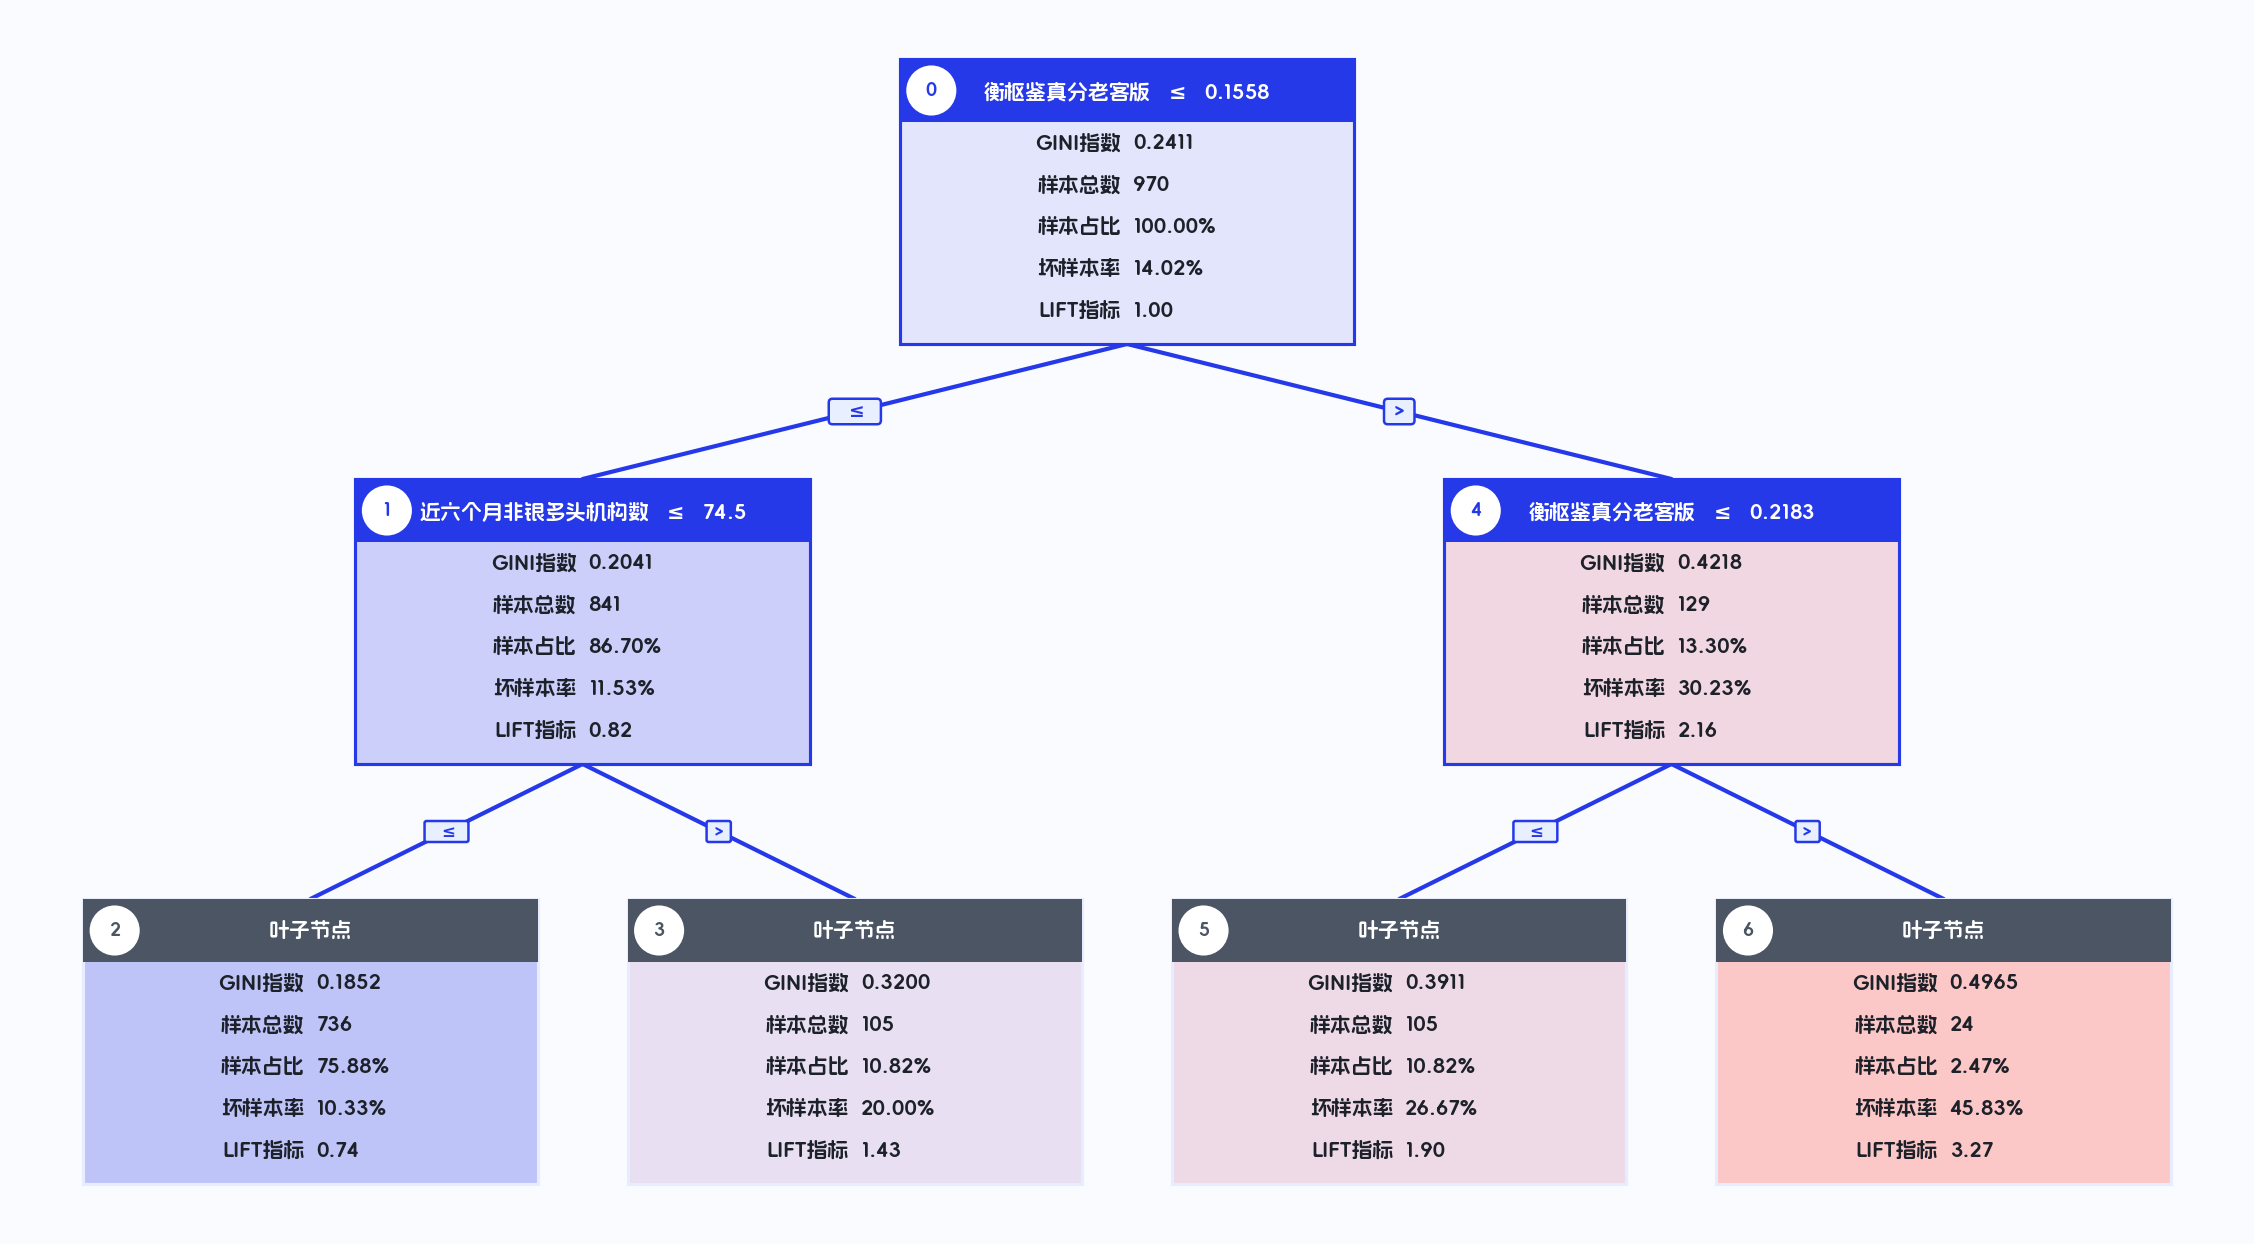

✅ matplotlib 渲染完成，图片已保存


In [22]:
# matplotlib 快速预览
# AntV G6 风格：卡片式节点 + 颜色语义 + 分支标签
fig = plot_tree_matplotlib(
    mte,
    figsize=(18, 12),
    dpi=150,
    save='tree_viz_output/cell04_matplotlib_basic.png',
)
plt.show()
print('✅ matplotlib 渲染完成，图片已保存')

---
## 5️⃣ pyecharts 交互式可视化

In [23]:
# pyecharts 交互式 HTML
# 支持鼠标悬停 tooltip / 缩放 / 平移 / 导出
chart = plot_tree_pyecharts(
    mte,
    title='决策树可视化 — AntV G6 风格',
    width='1400px',
    height='900px',
    save='tree_viz_output/cell05_pyecharts_basic.html',
)
chart.render_notebook()

---
## 6️⃣ graphviz 高质量矢量图

✅ graphviz 渲染完成


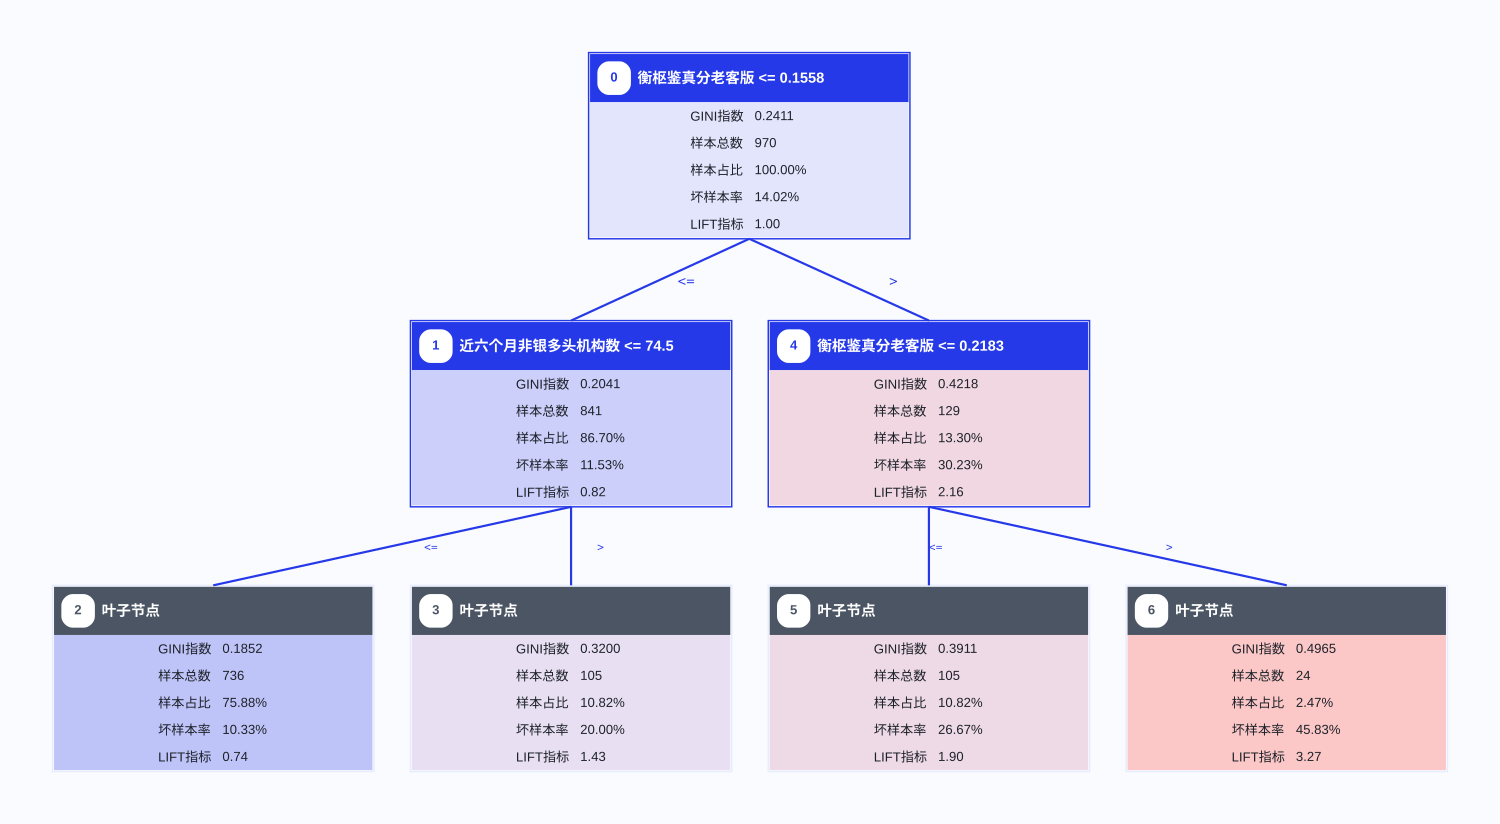

In [24]:
# graphviz 高质量矢量图（适合嵌入报告）
src = render_graphviz(
    plot_tree_graphviz,
    mte,
    save='tree_viz_output/cell06_graphviz_basic.png',
    figsize=(10, 6),
)
src

---
## 7️⃣ DecisionTreeViz 统一 API

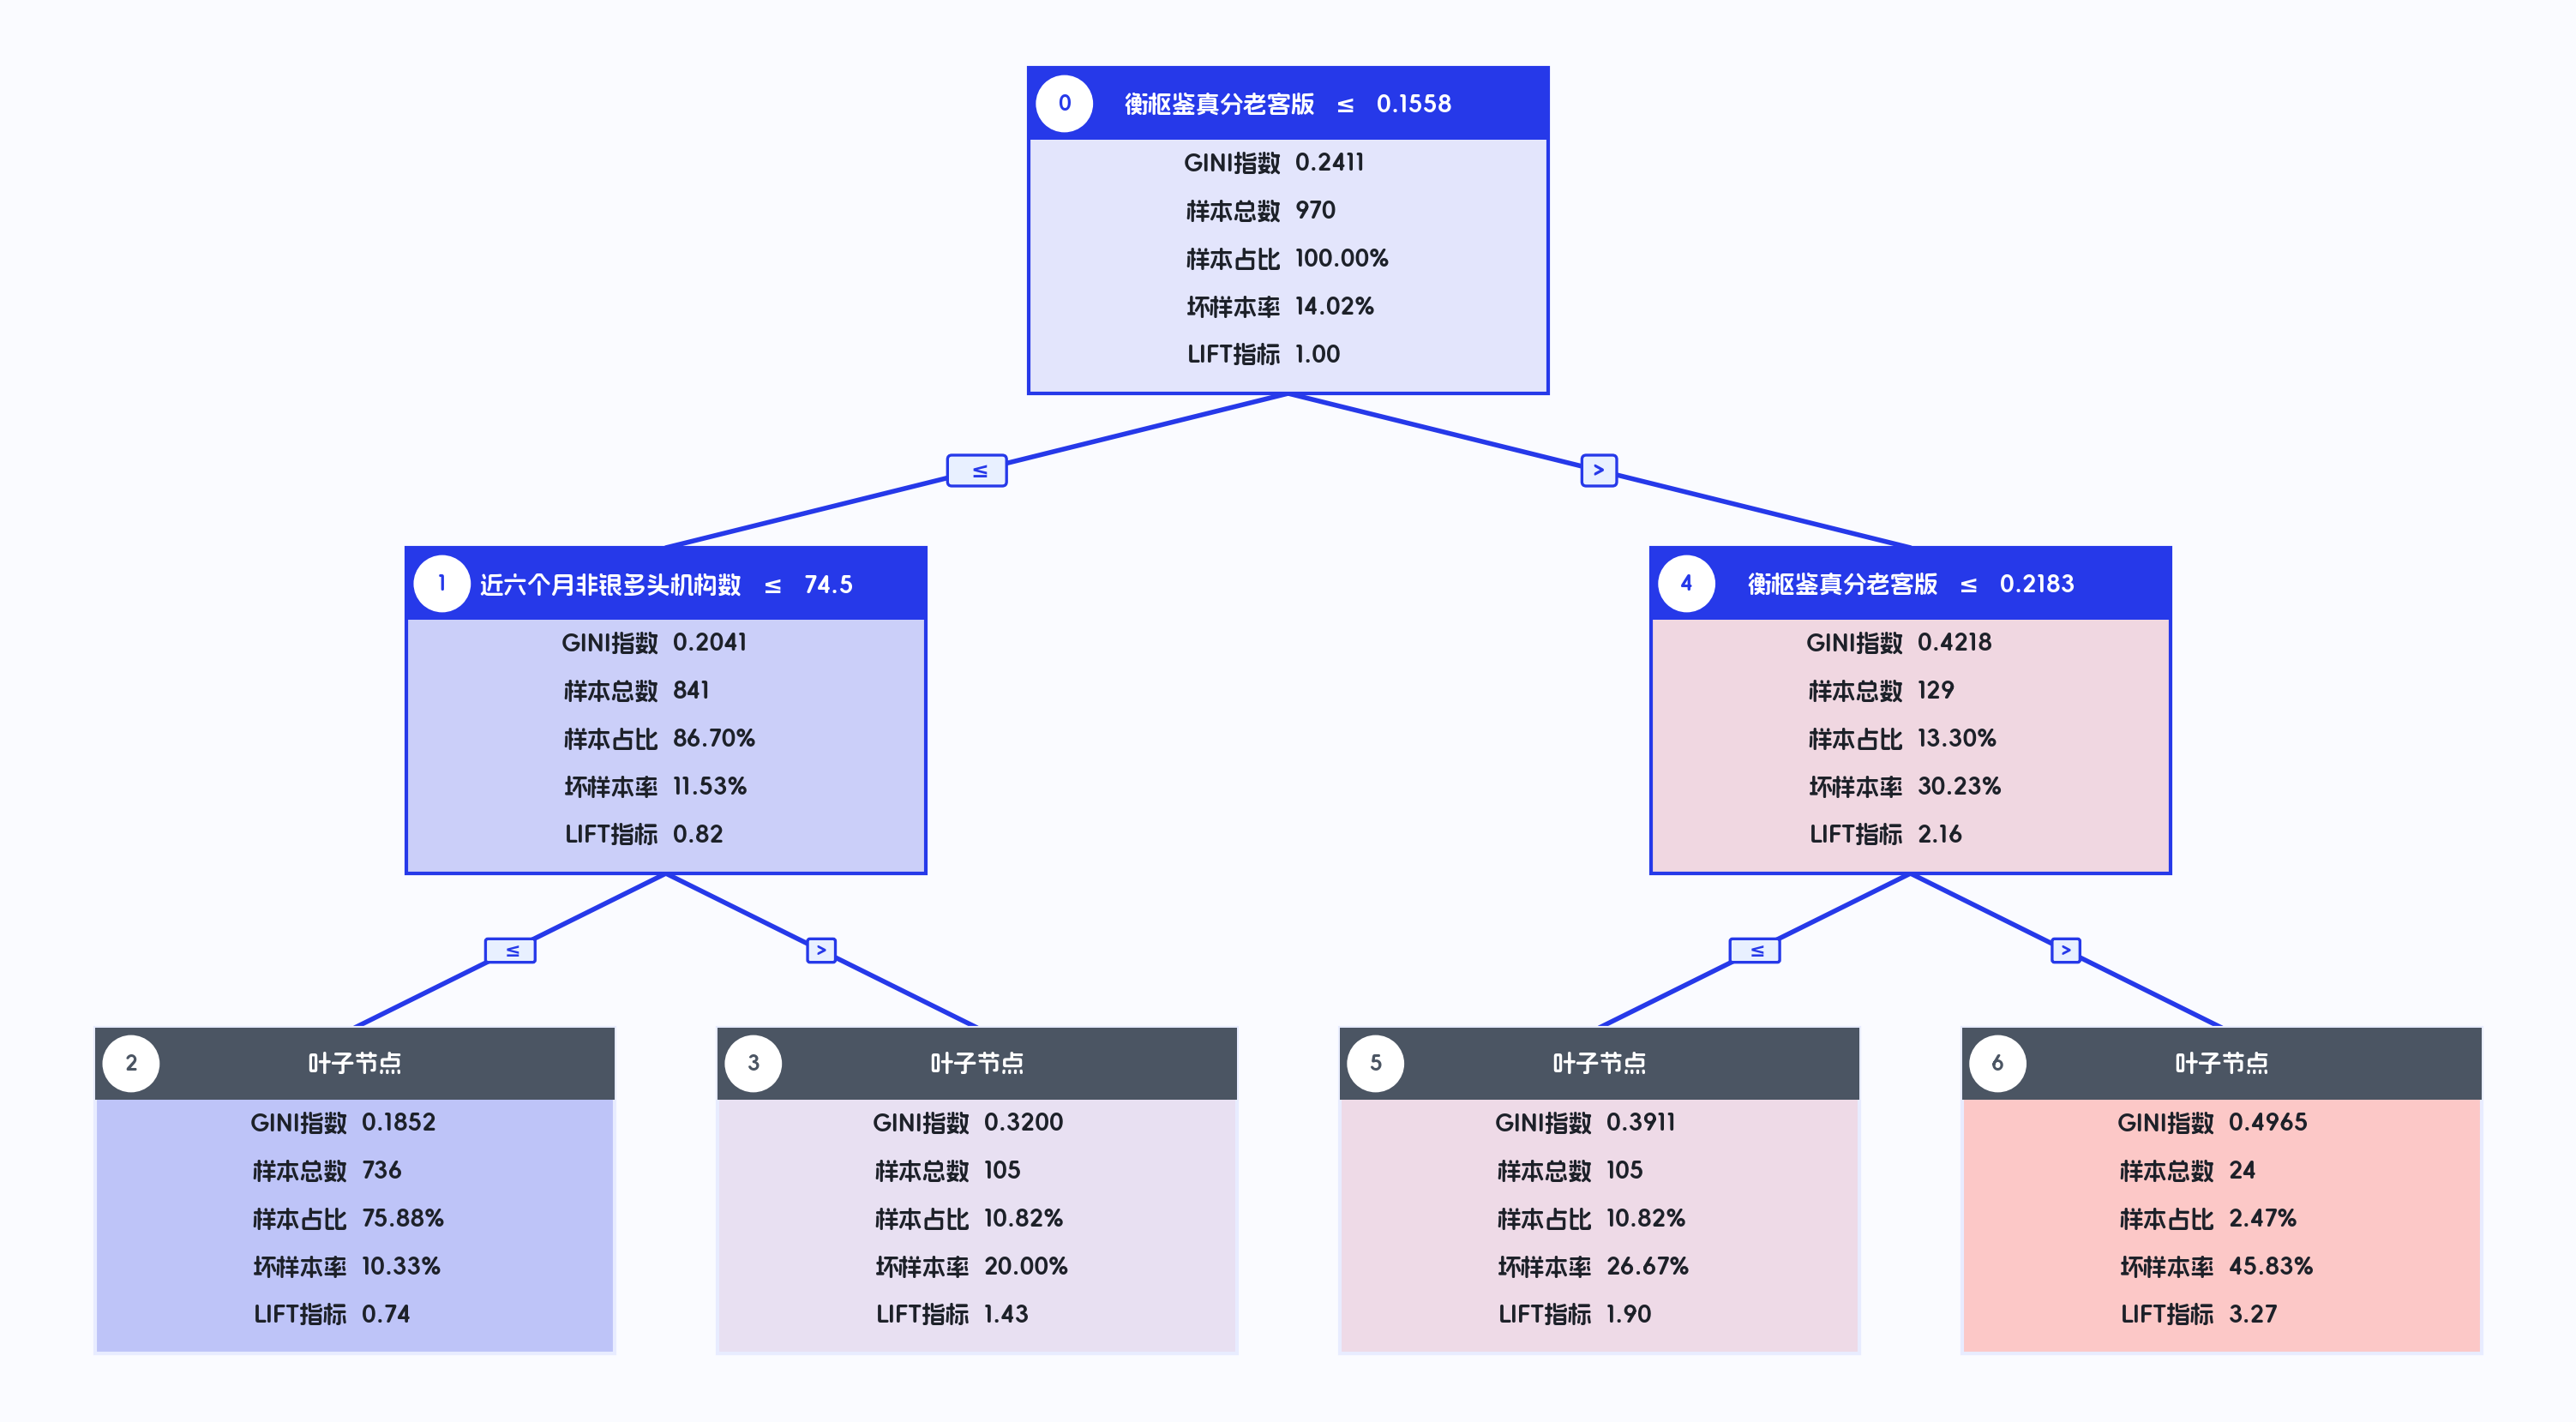

✅ DecisionTreeViz (matplotlib) 完成


In [25]:
# 统一 API：按需切换渲染后端
viz_mpl = DecisionTreeViz(backend='matplotlib', figsize=(18, 12), dpi=200)
fig = viz_mpl.plot(mte, save='tree_viz_output/cell07_unified_mpl.png')
plt.show()
print('✅ DecisionTreeViz (matplotlib) 完成')

In [26]:
viz_echarts = DecisionTreeViz(backend='pyecharts', title='决策树 — 统一 API')
chart = viz_echarts.plot(mte, save='tree_viz_output/cell07_unified_pyecharts.html')
chart.render_notebook()

In [27]:
viz_gv = DecisionTreeViz(backend='graphviz')
src = render_graphviz(viz_gv.plot, mte, save='tree_viz_output/cell07_unified_gv.png')

✅ DecisionTreeViz (graphviz) 完成


---
## 8️⃣ 人工分裂（manual_split）— 业务经验注入

**核心场景**：数据驱动模型学到的分裂点不符合业务经验，需要人工干预。

In [28]:
# 在实际根节点进行人工分裂；阈值取该特征的真实样本中位数
mte_manual = ManualTreeExtractor(
    target=TARGET,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
mte_manual.fit(df, features=feature_list)
root_node, root_data = select_root_data(df)
root_threshold = median_split_threshold(root_data, '衡枢鉴真分老客版')
mte_manual.manual_split(
    data=df,
    feature='衡枢鉴真分老客版',
    threshold=root_threshold,
    node=root_node,
)
print(f'✅ 人工分裂完成（根节点：衡枢鉴真分老客版 ≤ {root_threshold:.6g}）')
style_rule_table(mte_manual.get_rule_table(), overall_badrate=df[TARGET].mean())

✅ 人工分裂完成（根节点：衡枢鉴真分老客版 ≤ 600）


,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,是,衡枢鉴真分老客版 <= 600.0000,970,100.00%,834,100.00%,136,100.00%,14.02%,1.00,100.00%,100.00%,14.02%,14.02%,100.00%,24.59%
1,2,是,衡枢鉴真分老客版 > 600.0000(含缺失),0,0.00%,0,0.00%,0,0.00%,0.00%,0.00,0.00%,0.00%,85.98%,0.00%,0.00%,0.00%


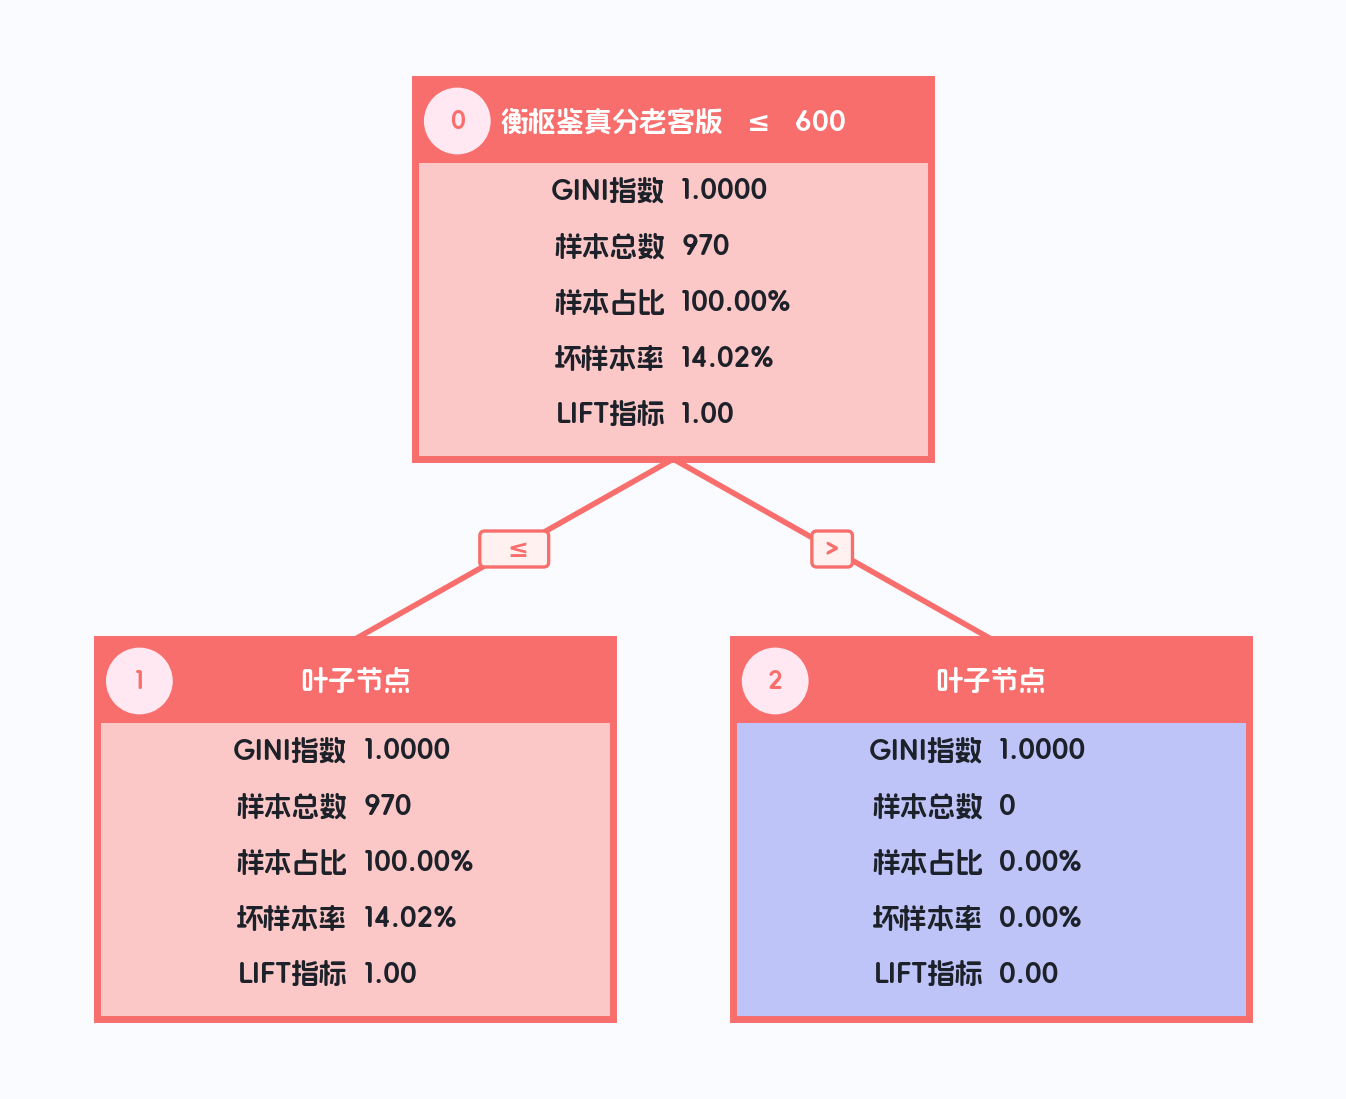

✅ matplotlib 可视化完成（紫色边框=人工分裂节点）


In [29]:
fig = plot_tree_matplotlib(
    mte_manual,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell08_manual_split_mpl.png',
)
plt.show()
print('✅ matplotlib 可视化完成（紫色边框=人工分裂节点）')

In [30]:
chart = plot_tree_pyecharts(
    mte_manual,
    title=f'人工分裂决策树 — 衡枢鉴真分老客版 ≤ {root_threshold:.6g}',
    save='tree_viz_output/cell08_manual_split_pyecharts.html',
)
chart.render_notebook()

In [31]:
src = render_graphviz(
    plot_tree_graphviz,
    mte_manual,
    save='tree_viz_output/cell08_manual_split_gv.png',
)

✅ graphviz 渲染完成


---
## 9️⃣ 多轮人工分裂 — 完整风控规则注入

In [32]:
# 多轮人工分裂完整示例
mte_full = ManualTreeExtractor(
    target=TARGET,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
mte_full.fit(df, features=feature_list)

# 每轮从当前规则表选择实际存在、路径可执行且样本非空的叶子节点；
# 每个阈值均由该节点命中样本的中位数确定，避免复用旧树节点 ID 或错误量纲。
full_split_nodes = apply_three_business_splits(mte_full, df)

print('✅ 多轮人工分裂完成')
style_rule_table(mte_full.get_rule_table(), overall_badrate=df[TARGET].mean())

✅ 多轮人工分裂完成


,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,衡枢鉴真分老客版 <= 0.1558(含缺失),841,86.70%,744,89.21%,97,71.32%,11.53%,0.82,-115.63%,-133.37%,19.28%,11.53%,71.32%,19.86%
1,2,否,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失),736,75.88%,660,79.14%,76,55.88%,10.33%,0.74,-82.88%,-109.23%,25.77%,10.33%,55.88%,17.43%
2,3,否,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000,105,10.82%,84,10.07%,21,15.44%,20.00%,1.43,5.18%,47.82%,79.48%,20.00%,15.44%,17.43%
3,4,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 <= 595.5000,52,5.36%,37,4.44%,15,11.03%,28.85%,2.06,5.99%,111.73%,83.71%,28.85%,11.03%,15.96%
4,5,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 > 595.5000(含缺失),53,5.46%,47,5.64%,6,4.41%,11.32%,0.81,-1.11%,-20.37%,81.75%,11.32%,4.41%,6.35%
5,6,否,衡枢鉴真分老客版 > 0.1558,129,13.30%,90,10.79%,39,28.68%,30.23%,2.16,17.74%,133.37%,80.72%,30.23%,28.68%,29.43%
6,7,否,衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1558,105,10.82%,77,9.23%,28,20.59%,26.67%,1.90,10.95%,101.14%,80.93%,26.67%,20.59%,23.24%
7,8,是,衡枢鉴真分老客版 <= 0.1681 且 衡枢鉴真分老客版 > 0.1558,32,3.30%,20,2.40%,12,8.82%,37.50%,2.67,5.71%,173.18%,85.15%,37.50%,8.82%,14.29%
8,9,是,衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1681,73,7.53%,57,6.83%,16,11.76%,21.92%,1.56,4.58%,60.91%,81.75%,21.92%,11.76%,15.31%
9,10,是,衡枢鉴真分老客版 > 0.2183,24,2.47%,13,1.56%,11,8.09%,45.83%,3.27,5.76%,232.66%,85.77%,45.83%,8.09%,13.75%


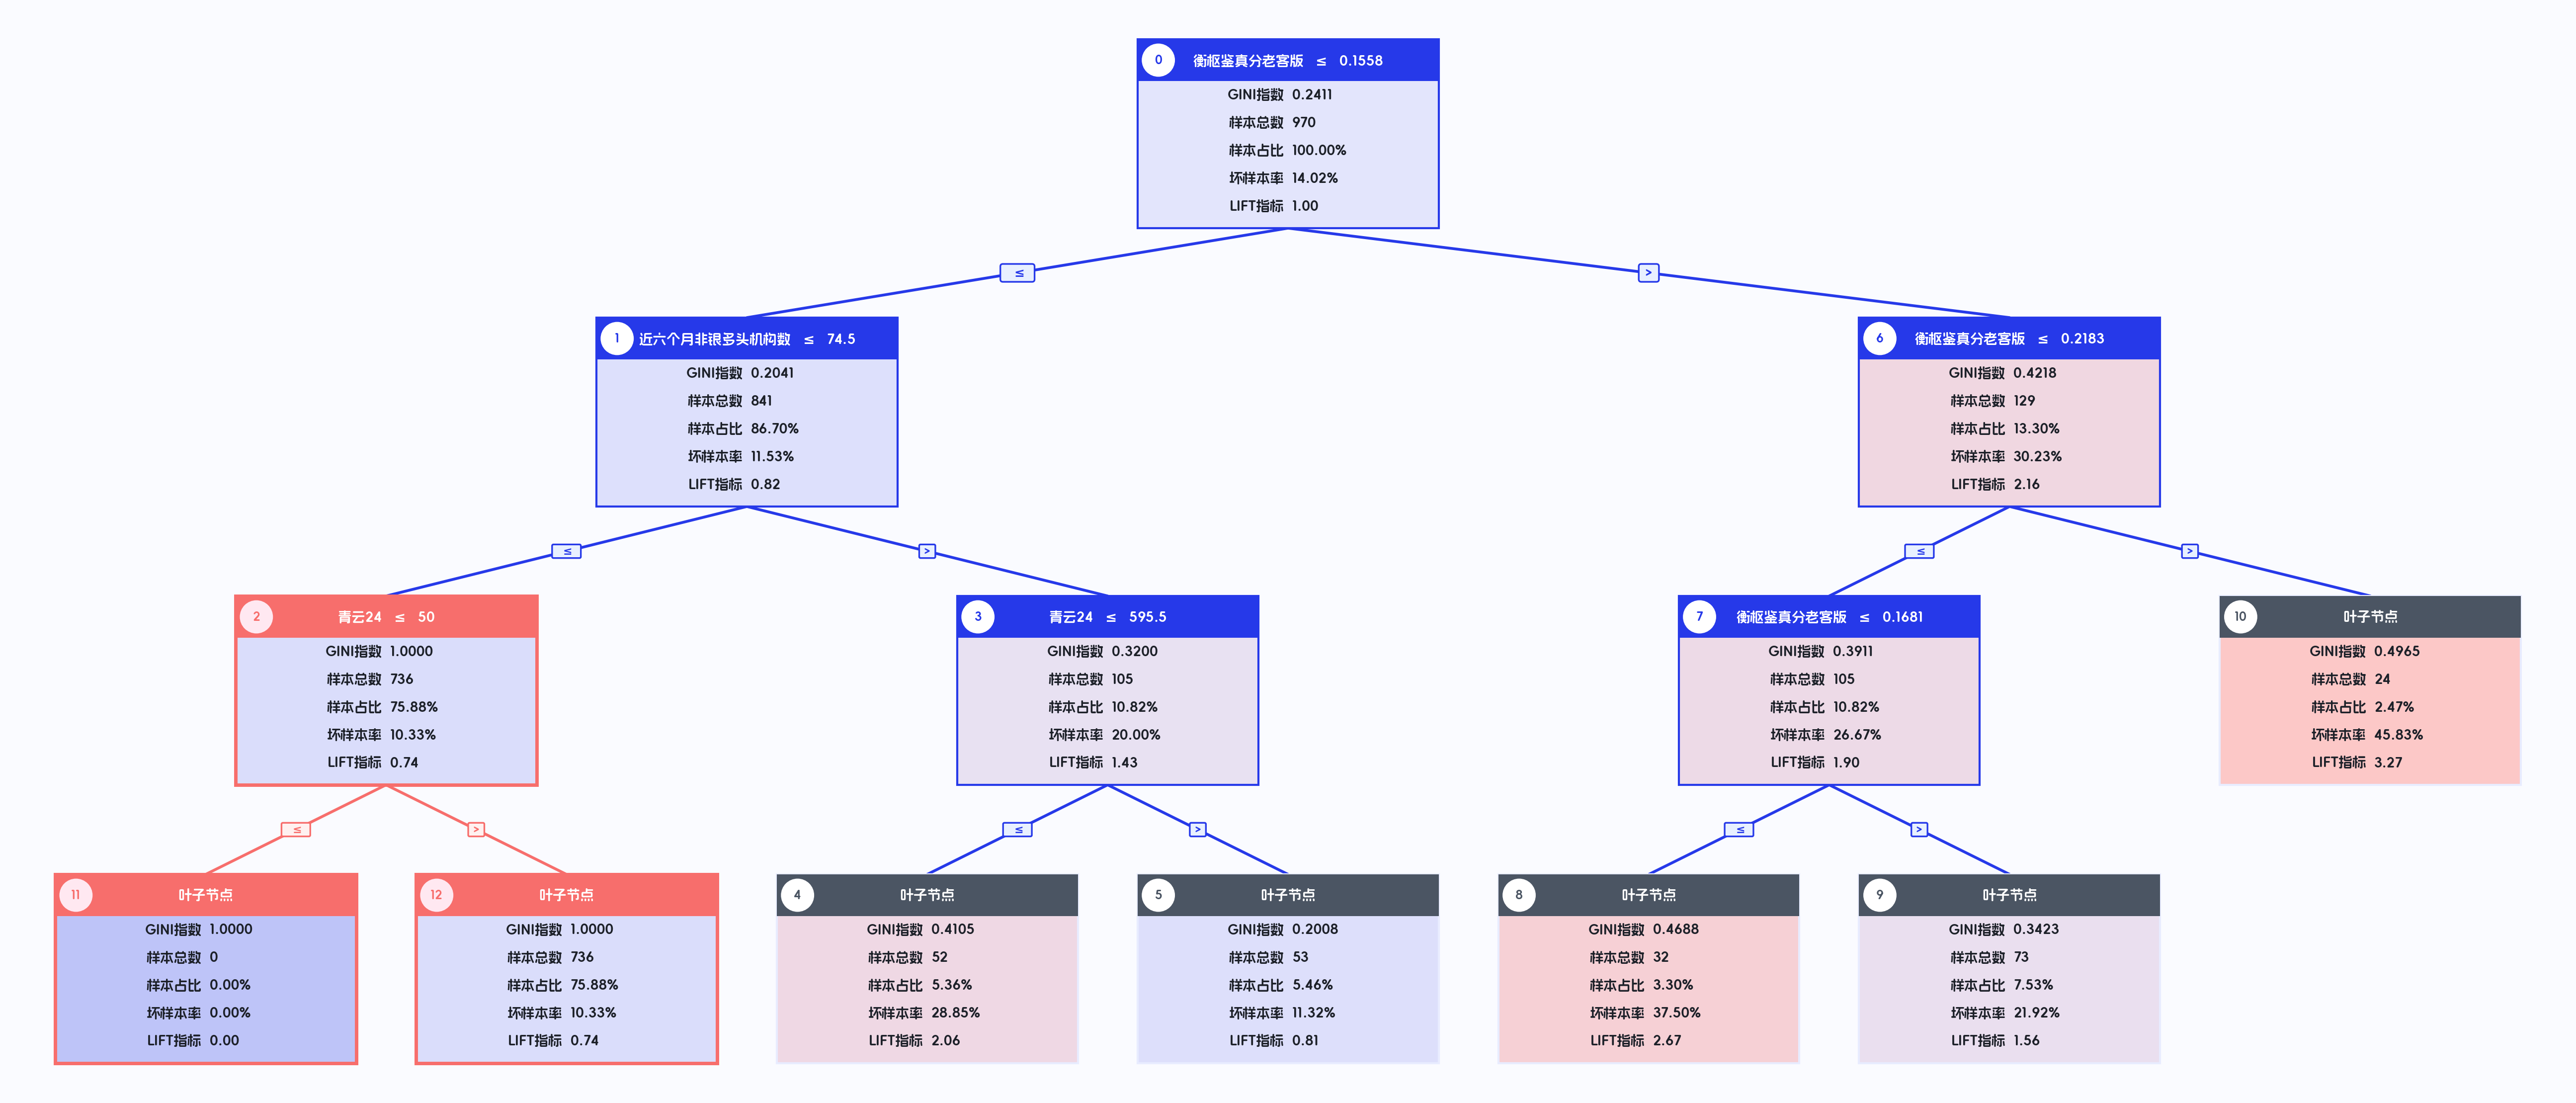

✅ matplotlib 完整树可视化完成


In [33]:
fig = plot_tree_matplotlib(
    mte_full,
    figsize=(22, 16),
    dpi=200,
    save='tree_viz_output/cell09_full_manual_mpl.png',
)
plt.show()
print('✅ matplotlib 完整树可视化完成')

In [34]:
chart = plot_tree_pyecharts(
    mte_full,
    # title='多轮人工分裂决策树 — 完整风控规则',
    save='tree_viz_output/cell09_full_manual_pyecharts.html',
)
chart.render_notebook()

✅ graphviz PDF 生成完成（适合报告嵌入）


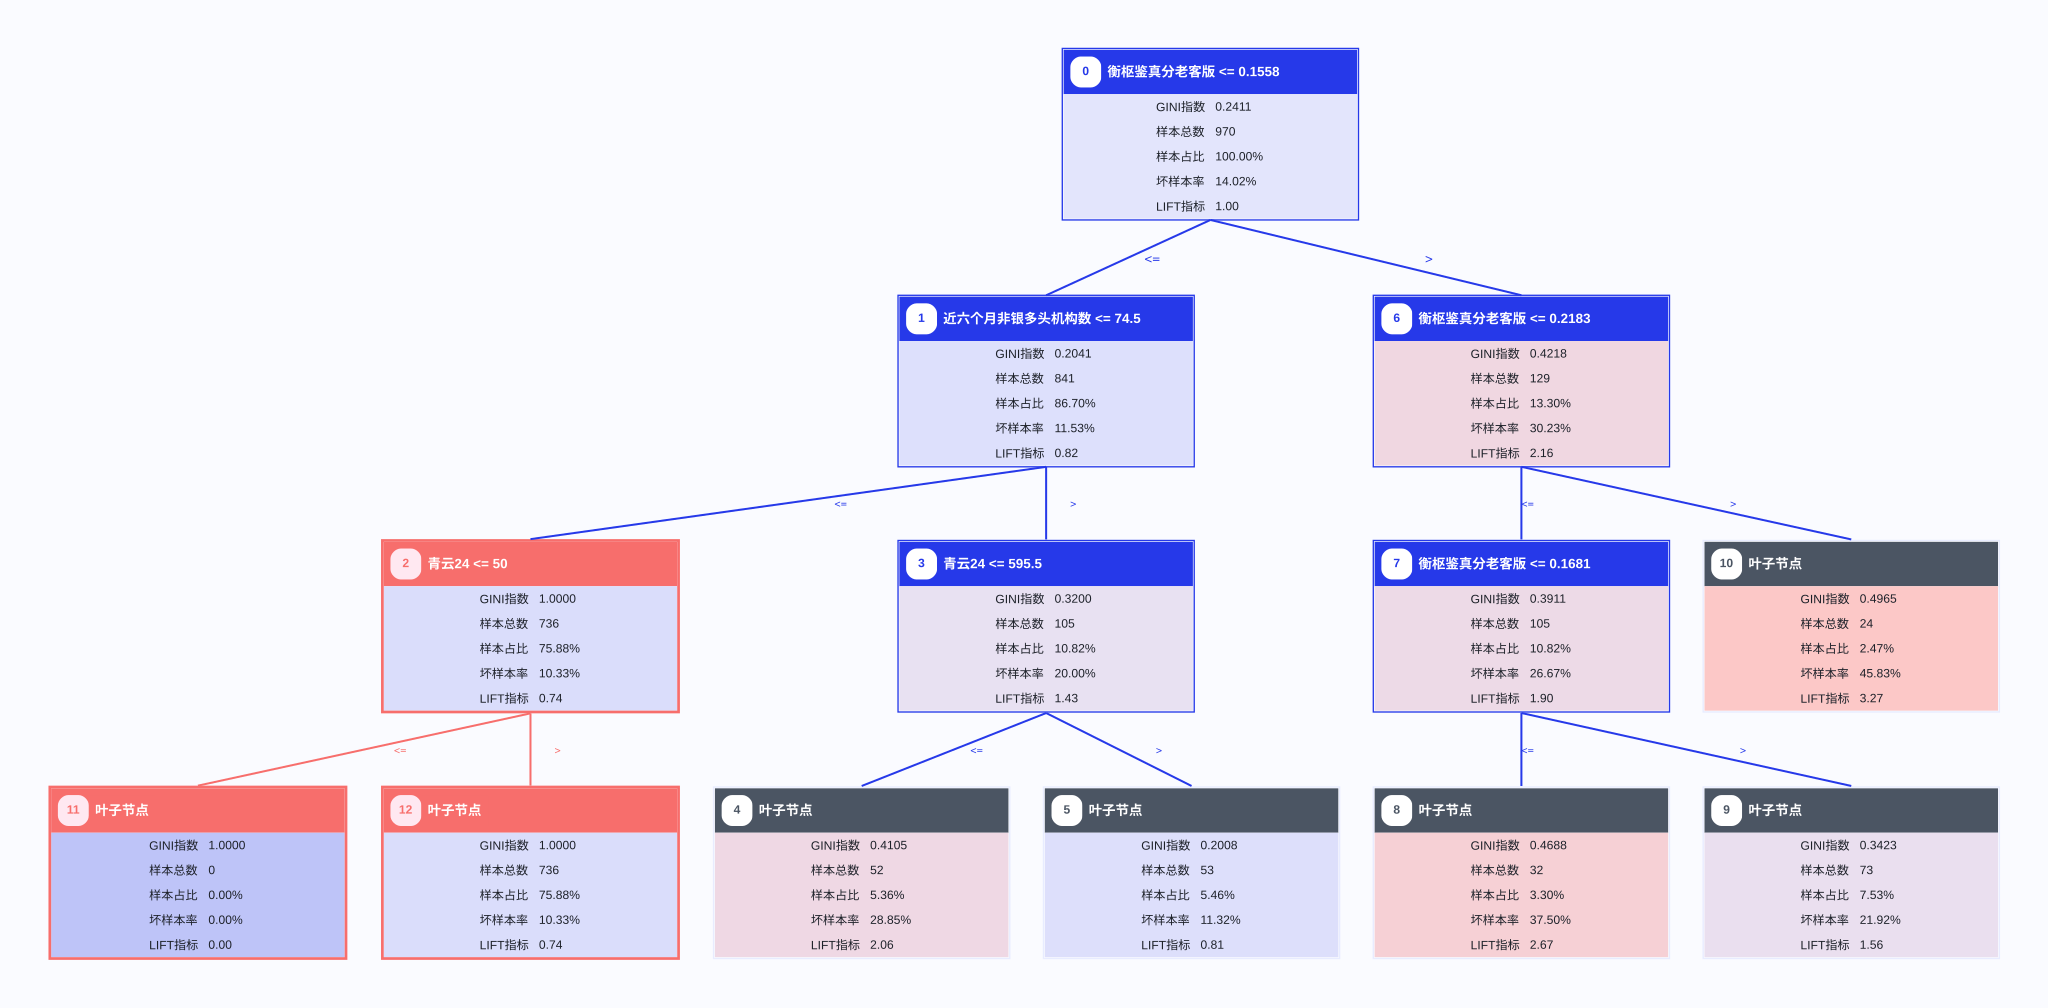

In [35]:
src = render_graphviz(
    plot_tree_graphviz,
    mte_full,
    save='tree_viz_output/cell09_full_manual_gv.pdf',
)
src

---
## 🔟 删除节点（delete_node）— 简化树结构

In [36]:
# 将指定节点及其子树裁剪为叶子节点
mte_pruned = ManualTreeExtractor(
    target=TARGET, max_depth=3,
    min_samples_split=50, min_samples_leaf=20, random_state=42,
)
mte_pruned.fit(df, features=feature_list)
pruned_split_nodes = apply_three_business_splits(mte_pruned, df)

before_table = mte_pruned.get_rule_table(df)
prune_node = pruned_split_nodes['first_branch']
prune_row = before_table[before_table['节点编号'] == prune_node]
assert len(prune_row) == 1 and int(prune_row.iloc[0]['样本总数']) > 0
print(
    f"删除节点证据：node={prune_node}，路径={prune_row.iloc[0]['指标含义']}，"
    f"样本数={int(prune_row.iloc[0]['样本总数'])}"
)
print(f'删除前节点数：{len(before_table)}')
mte_pruned.delete_node(node=prune_node)
after_table = mte_pruned.get_rule_table(df)
after_row = after_table[after_table['节点编号'] == prune_node]
assert len(after_row) == 1 and after_row.iloc[0]['是否叶子'] == '是'
print(f'删除后节点数：{len(after_table)}；node={prune_node} 已成为叶子节点')
style_rule_table(after_table, overall_badrate=df[TARGET].mean())

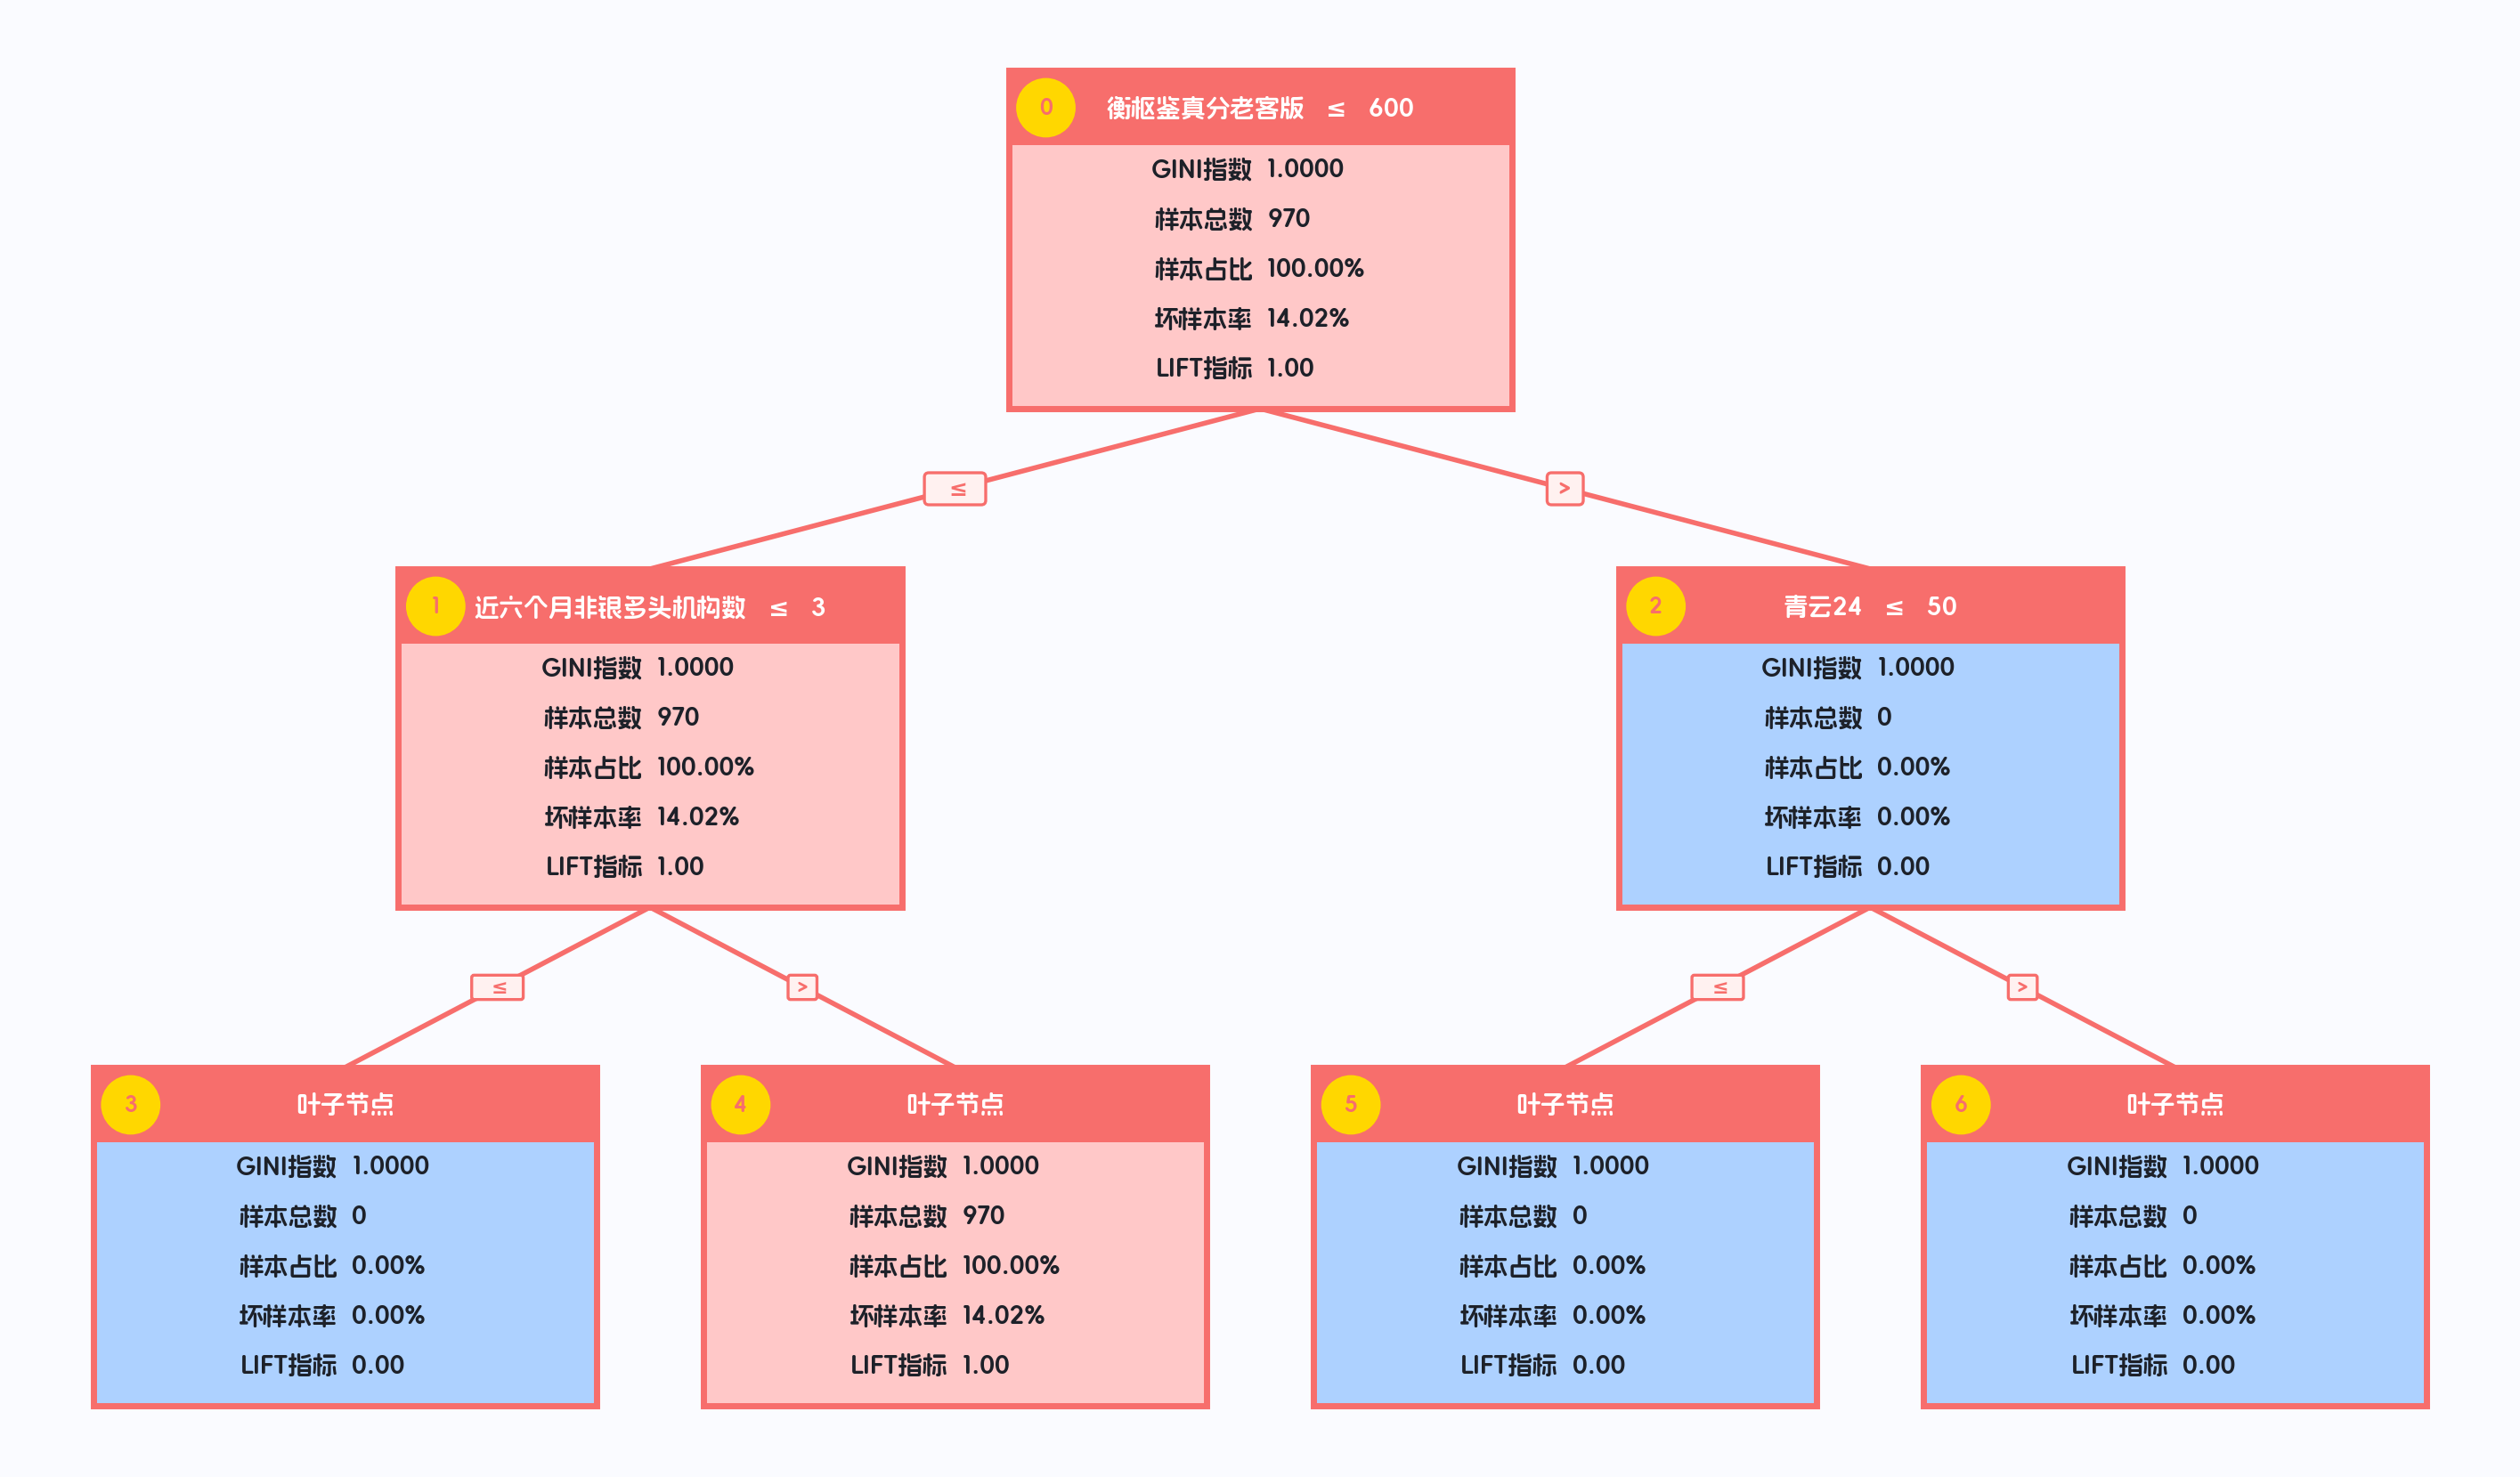

✅ 裁剪后树可视化完成


In [ ]:
fig = plot_tree_matplotlib(
    mte_pruned,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell10_pruned_mpl.png',
)
plt.show()
print('✅ 裁剪后树可视化完成')

---
## 1️⃣1️⃣ DecisionTreeAnalyzer 可视化

In [ ]:
# DecisionTreeAnalyzer 是标准 sklearn 决策树包装器
fitter = DecisionTreeAnalyzer(
    target=TARGET,
    features=feature_list,
    tree_params={'max_depth': 3, 'min_samples_split': 50, 'random_state': 42},
)
fitter.fit(df)
print(f'✅ DecisionTreeAnalyzer 训练完成：{repr(fitter)}')
style_rule_table(fitter.get_rule_table(), overall_badrate=df[TARGET].mean())

✅ DecisionTreeAnalyzer 训练完成：DecisionTreeAnalyzer(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '青云24'], leaves=6)


,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,衡枢鉴真分老客版 <= 0.1558(含缺失),841,86.70%,744,89.21%,97,71.32%,11.53%,0.82,-115.63%,-133.37%,19.28%,11.53%,71.32%,19.86%
1,2,否,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 87.5000(含缺失),835,86.08%,741,88.85%,94,69.12%,11.26%,0.80,-121.90%,-141.60%,19.28%,11.26%,69.12%,19.36%
2,3,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失),736,75.88%,660,79.14%,76,55.88%,10.33%,0.74,-82.88%,-109.23%,25.77%,10.33%,55.88%,17.43%
3,4,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 87.5000 且 近六个月非银多头机构数 > 74.5000,99,10.21%,81,9.71%,18,13.24%,18.18%,1.30,3.37%,33.05%,79.48%,18.18%,13.24%,15.32%
4,5,是,衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 87.5000,6,0.62%,3,0.36%,3,2.21%,50.00%,3.57,1.60%,258.21%,85.98%,50.00%,2.21%,4.23%
5,6,否,衡枢鉴真分老客版 > 0.1558,129,13.30%,90,10.79%,39,28.68%,30.23%,2.16,17.74%,133.37%,80.72%,30.23%,28.68%,29.43%
6,7,是,衡枢鉴真分老客版 > 0.1558 且 青云24 <= 490.5000,8,0.82%,8,0.96%,0,0.00%,0.00%,0.00,-0.83%,-100.83%,85.15%,0.00%,0.00%,0.00%
7,8,否,衡枢鉴真分老客版 > 0.1558 且 青云24 > 490.5000(含缺失),121,12.47%,82,9.83%,39,28.68%,32.23%,2.30,18.51%,148.40%,81.55%,32.23%,28.68%,30.35%
8,9,是,衡枢鉴真分老客版 <= 0.2081 且 衡枢鉴真分老客版 > 0.1558 且 青云24 > 490.5000(含缺失),95,9.79%,69,8.27%,26,19.12%,27.37%,1.95,10.34%,105.54%,81.55%,27.37%,19.12%,22.51%
9,10,是,衡枢鉴真分老客版 > 0.2081 且 青云24 > 490.5000(含缺失),26,2.68%,13,1.56%,13,9.56%,50.00%,3.57,7.07%,263.69%,85.98%,50.00%,9.56%,16.05%


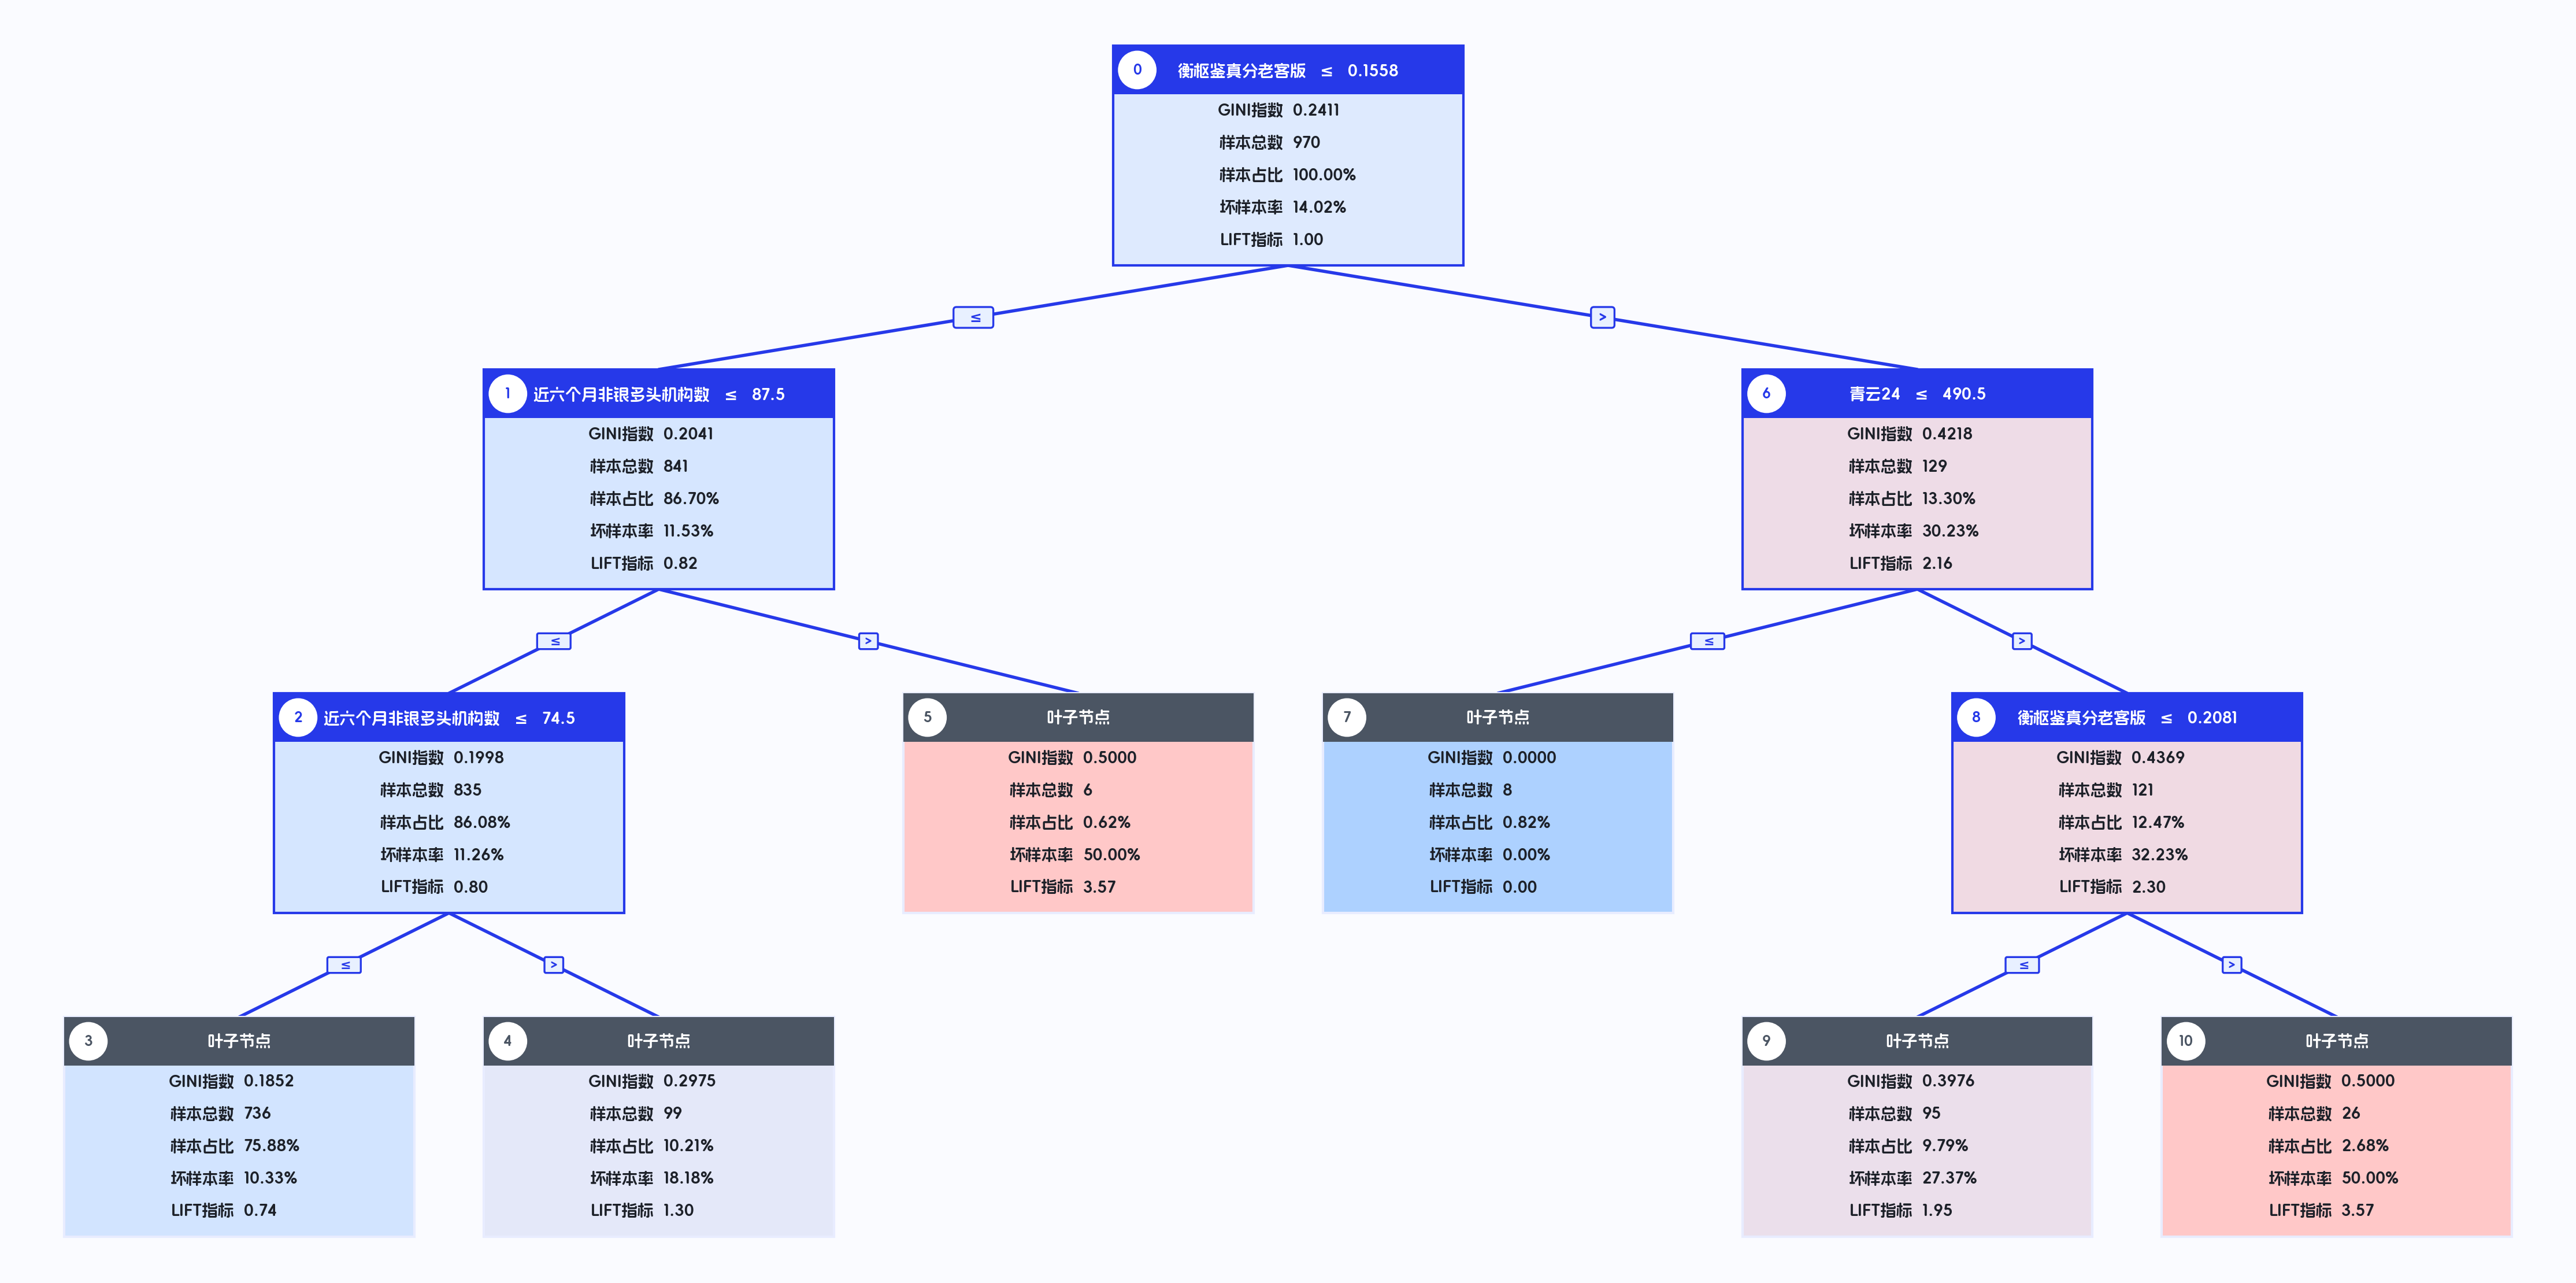

✅ DecisionTreeAnalyzer matplotlib 可视化完成


In [ ]:
fig = plot_tree_matplotlib(
    fitter,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell11_autofitter_mpl.png',
)
plt.show()
print('✅ DecisionTreeAnalyzer matplotlib 可视化完成')

In [ ]:
chart = plot_tree_pyecharts(
    fitter,
    title='DecisionTreeAnalyzer — 标准决策树',
    save='tree_viz_output/cell11_autofitter_pyecharts.html',
)
chart.render_notebook()

In [ ]:
src = render_graphviz(
    plot_tree_graphviz,
    fitter,
    save='tree_viz_output/cell11_autofitter_gv.pdf',
)

✅ DecisionTreeAnalyzer graphviz 渲染完成


---
## 1️⃣2️⃣ sklearn DecisionTreeClassifier 可视化

直接传入 sklearn 决策树对象，无需任何包装。

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
X = df[feature_list].values
y = df[TARGET].values
clf.fit(X, y)
print(f'✅ sklearn 决策树训练完成：节点数={clf.tree_.node_count}, 叶子数={clf.get_n_leaves()}')

✅ sklearn 决策树训练完成：节点数=13, 叶子数=7


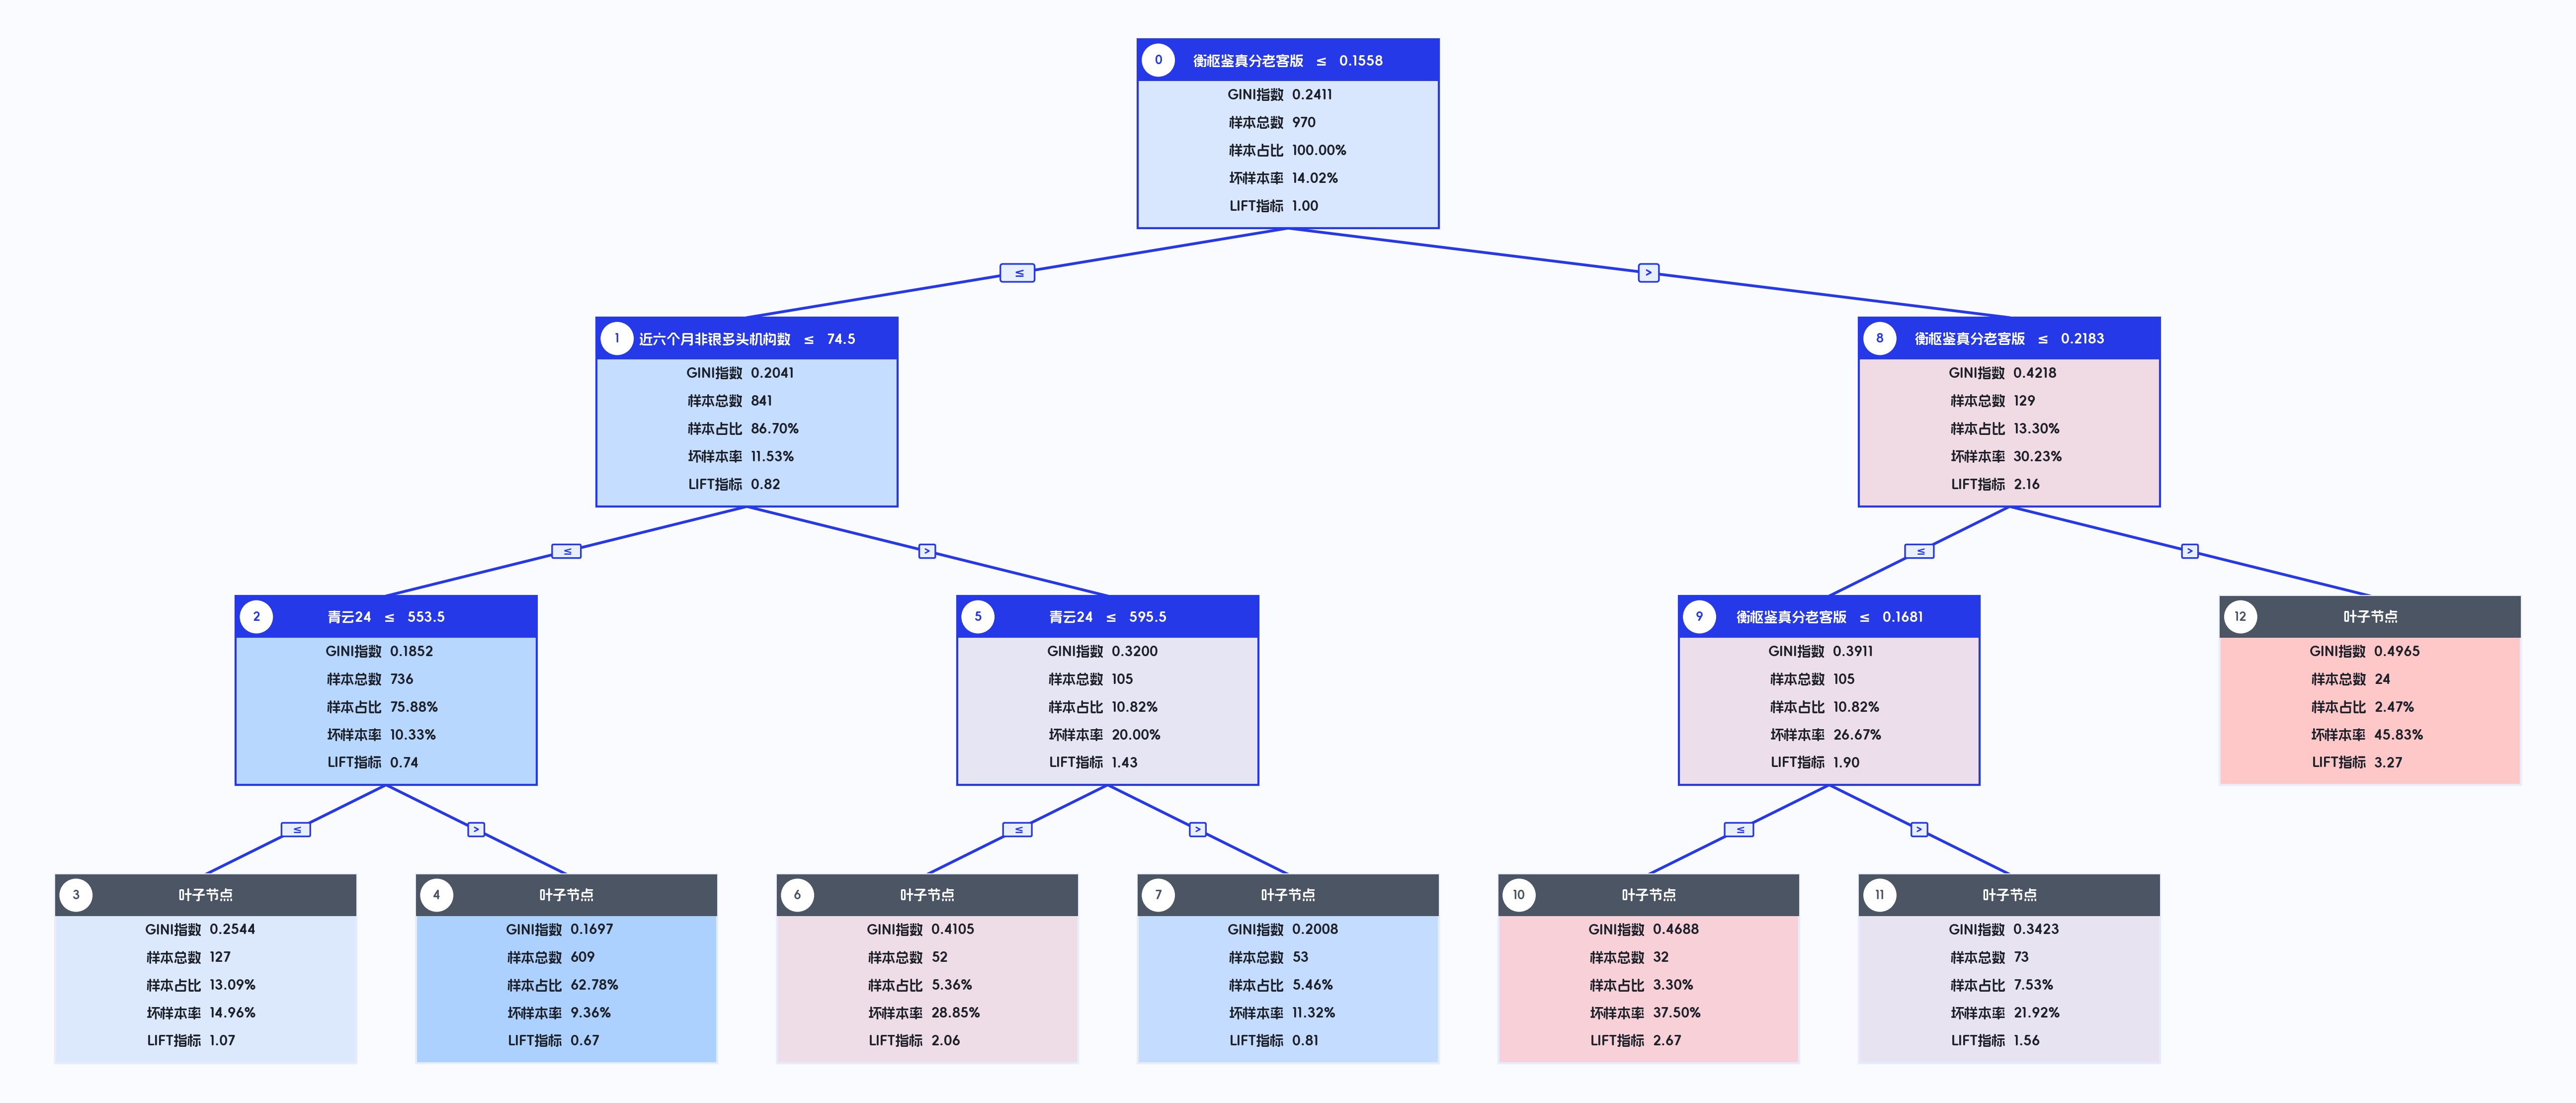

✅ sklearn DecisionTreeClassifier matplotlib 可视化完成


In [ ]:
fig = plot_tree_matplotlib(
    clf,
    feature_names=feature_list,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell12_sklearn_mpl.png',
)
plt.show()
print('✅ sklearn DecisionTreeClassifier matplotlib 可视化完成')

In [ ]:
chart = plot_tree_pyecharts(
    clf,
    feature_names=feature_list,
    title='sklearn DecisionTreeClassifier',
    save='tree_viz_output/cell12_sklearn_pyecharts.html',
)
chart.render_notebook()

In [ ]:
src = render_graphviz(
    plot_tree_graphviz,
    clf,
    feature_names=feature_list,
    save='tree_viz_output/cell12_sklearn_gv.pdf',
)

✅ sklearn DecisionTreeClassifier graphviz 渲染完成


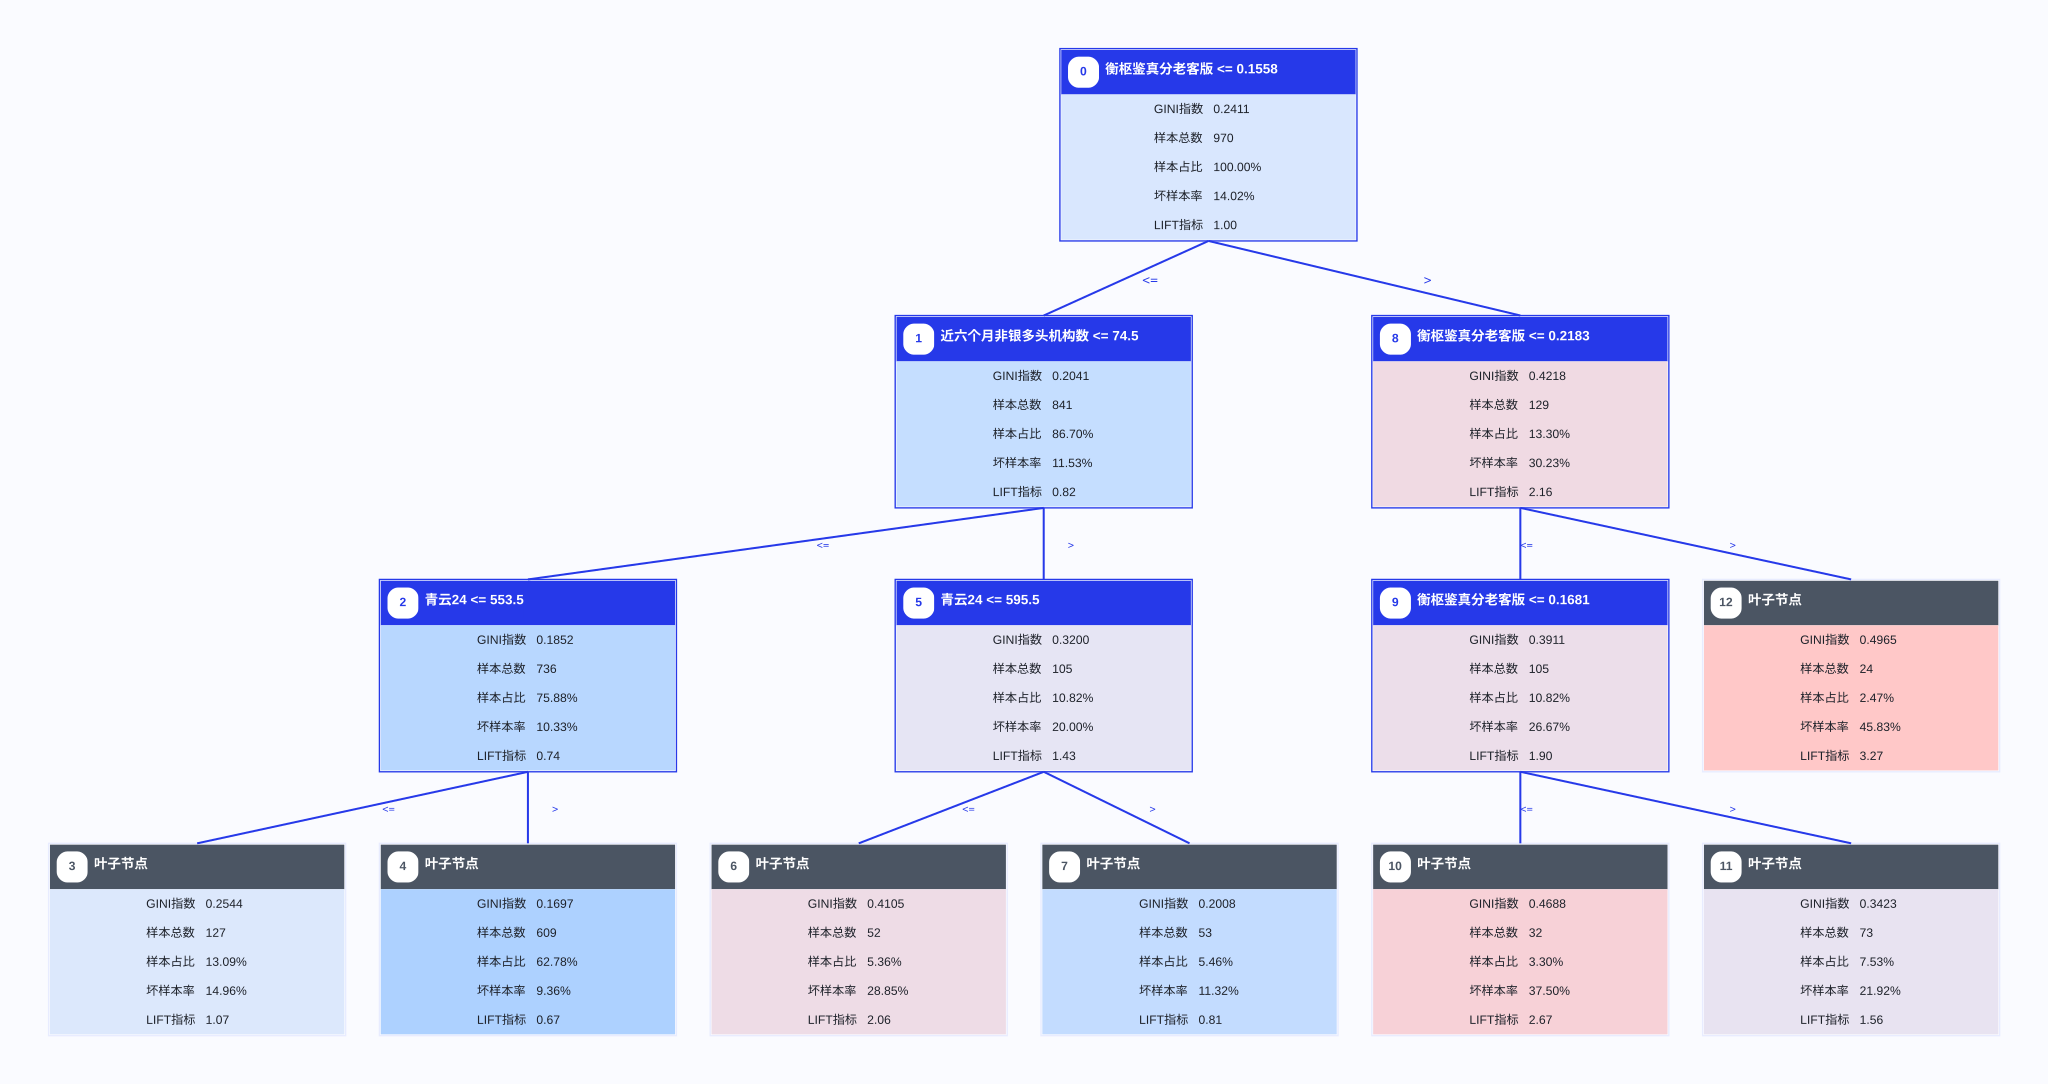

In [ ]:
src = render_graphviz(
    plot_tree_graphviz,
    clf,
    feature_names=feature_list,
)

---
## 1️⃣3️⃣ 从 sklearn 导入后人工分裂

In [ ]:
# 通过 from_sklearn() 从已训练的 sklearn 树创建 ManualTreeExtractor
mte_from_sklearn = ManualTreeExtractor.from_sklearn(
    clf,
    feature_names=feature_list,
    target=TARGET,
)
root_node, root_data = select_root_data(df)
from_sklearn_threshold = median_split_threshold(root_data, '衡枢鉴真分老客版')
mte_from_sklearn.manual_split(
    df, feature='衡枢鉴真分老客版', threshold=from_sklearn_threshold, node=root_node
)
print('✅ 从 sklearn 导入并人工分裂完成')
# from_sklearn 创建的提取器未保存训练数据，需显式传入数据集计算规则效果
style_rule_table(mte_from_sklearn.get_rule_table(df), overall_badrate=df[TARGET].mean())

✅ 从 sklearn 导入并人工分裂完成


,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,是,衡枢鉴真分老客版 <= 600.0000,970,100.00%,834,100.00%,136,100.00%,14.02%,1.00,100.00%,100.00%,14.02%,14.02%,100.00%,24.59%
1,2,是,衡枢鉴真分老客版 > 600.0000(含缺失),0,0.00%,0,0.00%,0,0.00%,0.00%,0.00,0.00%,0.00%,85.98%,0.00%,0.00%,0.00%


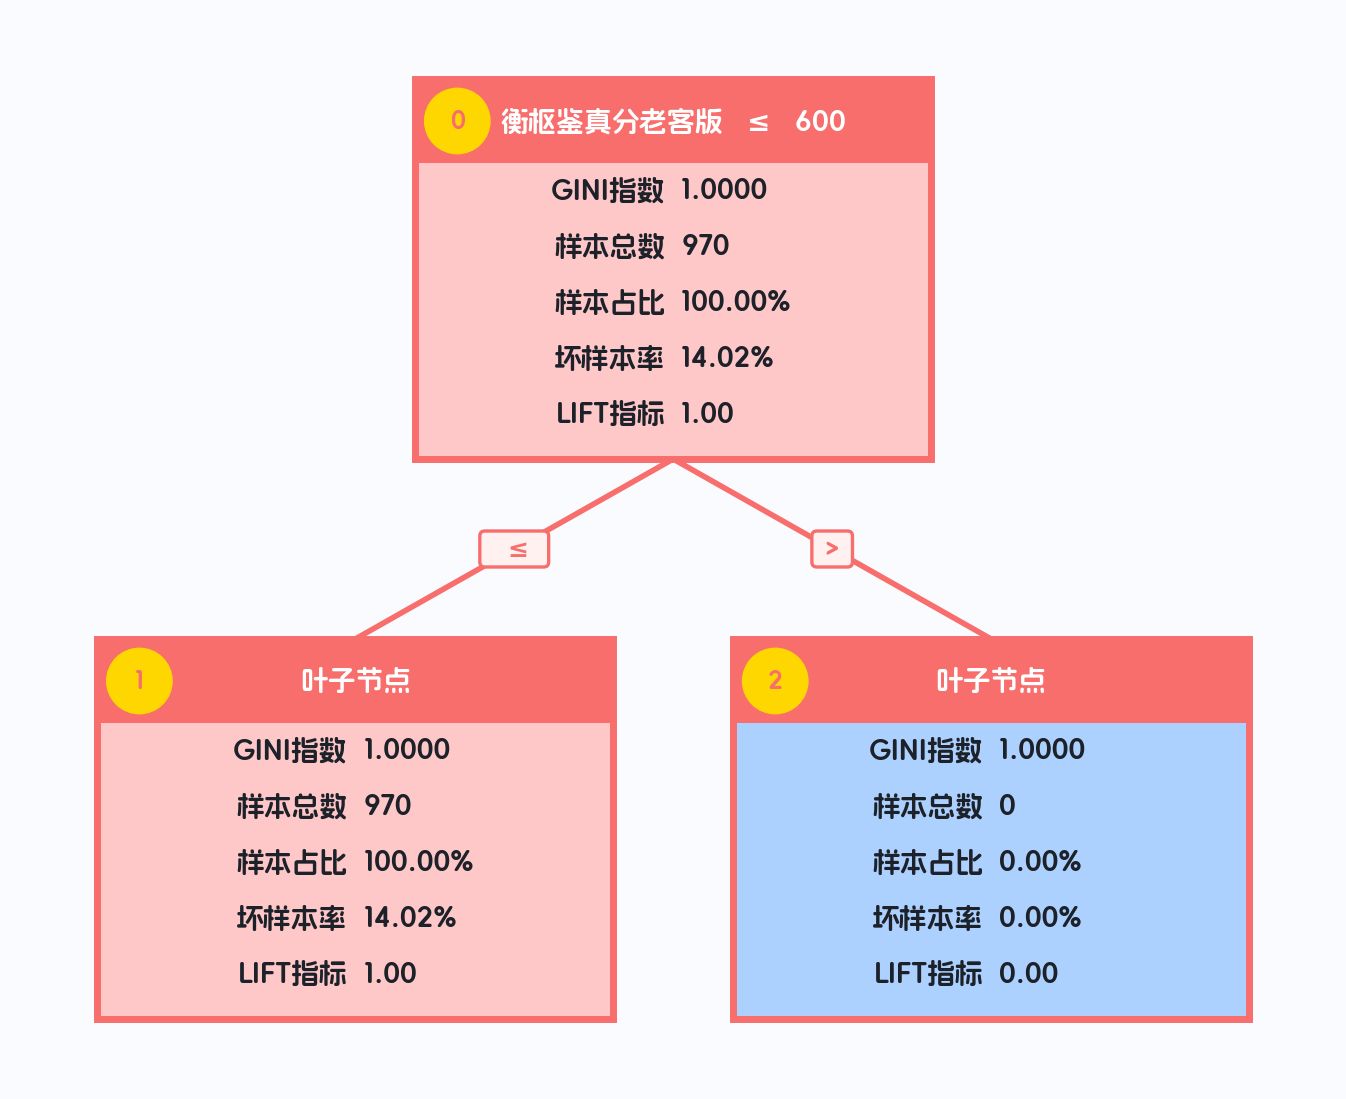

In [ ]:
fig = plot_tree_matplotlib(
    mte_from_sklearn,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell13_from_sklearn_mpl.png',
)
plt.show()

In [ ]:
chart = plot_tree_pyecharts(
    mte_from_sklearn,
    title='从 sklearn 导入后人工分裂',
    save='tree_viz_output/cell13_from_sklearn_pyecharts.html',
)
chart.render_notebook()

---
## 1️⃣4️⃣ 在新数据集上评估人工决策树

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

# 在测试集上评估人工决策树
eval_result = mte_full.report(df_test, overdue='MOB1', dpds=[3, 1])
print('📊 测试集评估结果：')
eval_result

📊 测试集评估结果：


分箱详情                                                                                                                                                                                                                                                                   MOB1 3+         ... MOB1 1+                                                                 
   节点编号 是否叶子  规则分类                                                                                                                                                      指标名称                                                                         指标含义  分箱 样本总数   样本占比    好样本数  好样本占比  ...    坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善   风险拒绝比    准确率    精确率    召回率   F1分数
0     1    否  验证规则                                                                                              ((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))                                                      衡枢鉴真分老客版 <= 0.1558(含缺失)  命中  255 0.8763     223 0.8956  ...      34 0.7727 0.1333 0.8818 -0.8371 -0.9553 0.2062 0.1333 0.7727 0.2274
1     2    否  验证规则                                     ((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((近六个月非银多头机构数 <= 74.5) | (近六个月非银多头机构数 != 近六个月非银多头机构数))                        衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失)  命中  225 0.7732     199 0.7992  ...      28 0.6364 0.1244 0.8230 -0.6033 -0.7803 0.2680 0.1244 0.6364 0.2082
2     3    否  验证规则                                                                       ((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (近六个月非银多头机构数 > 74.5)                              衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000  命中   30 0.1031      24 0.0964  ...       6 0.1364 0.2000 1.3227  0.0371  0.3598 0.7869 0.2000 0.1364 0.1622
3     4    是  验证规则                                                     ((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (近六个月非银多头机构数 > 74.5) & (青云24 <= 595.5)           衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 <= 595.5000  命中   13 0.0447       9 0.0361  ...       4 0.0909 0.3077 2.0350  0.0484  1.0834 0.8316 0.3077 0.0909 0.1404
4     5    是  验证规则                                   ((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (近六个月非银多头机构数 > 74.5) & ((青云24 > 595.5) | (青云24 != 青云24))       衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 > 595.5000(含缺失)  命中   17 0.0584      15 0.0602  ...       2 0.0455 0.1176 0.7781 -0.0138 -0.2357 0.8041 0.1176 0.0455 0.0656
5     6    否  验证规则                                                                                                                          (衡枢鉴真分老客版 > 0.15583351254463196)                                                            衡枢鉴真分老客版 > 0.1558  命中   36 0.1237      26 0.1044  ...      10 0.2273 0.2778 1.8371  0.1182  0.9553 0.7938 0.2778 0.2273 0.2500
6     7    否  验证规则                                                                                      (衡枢鉴真分老客版 <= 0.21834629029035568) & (衡枢鉴真分老客版 > 0.15583351254463196)                                       衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1558  命中   27 0.0928      20 0.0803  ...       7 0.1591 0.2593 1.7146  0.0731  0.7877 0.8041 0.2593 0.1591 0.1972
7     8    是  验证规则                                                                                      (衡枢鉴真分老客版 <= 0.16805626451969147) & (衡枢鉴真分老客版 > 0.15583351254463196)                                       衡枢鉴真分老客版 <= 0.1681 且 衡枢鉴真分老客版 > 0.1558  命中    7 0.0241       5 0.0201  ...       2 0.0455 0.2857 1.8896  0.0219  0.9115 0.8385 0.2857 0.0455 0.0784
8     9    是  验证规则                                                                                      (衡枢鉴真分老客版 <= 0.21834629029035568) & (衡枢鉴真分老客版 > 0.16805626451969147)                                       衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1681  命中   20 0.0687      15 0.0602  ...       5 0.1136 0.2500 1.6534  0.0482  0.7016 0.8144 0.2500 0.1136 0.1562
9    10    是  验证规则                                    

In [ ]:
# 仅评估叶子节点（核心风控规则）
leaf_result = mte_full.report(df_test, leaf_only=True)
print('📊 叶子节点评估结果（核心风控规则）：')
leaf_result

📊 叶子节点评估结果（核心风控规则）：


,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,4,是,验证规则,((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (近六个月非银多头机构数 > 74.5) & (青云24 <= 595.5),衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 <= 595.5000,命中,13,0.0447,10,0.0394,3,0.0811,0.2308,1.8150,0.0381,0.8531,0.8488,0.2308,0.0811,0.1200
1,5,是,验证规则,((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & (近六个月非银多头机构数 > 74.5) & ((青云24 > 595.5) | (青云24 != 青云24)),衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 > 595.5000(含缺失),命中,17,0.0584,16,0.0630,1,0.0270,0.0588,0.4626,-0.0333,-0.5707,0.8213,0.0588,0.0270,0.0370
2,8,是,验证规则,(衡枢鉴真分老客版 <= 0.16805626451969147) & (衡枢鉴真分老客版 > 0.15583351254463196),衡枢鉴真分老客版 <= 0.1681 且 衡枢鉴真分老客版 > 0.1558,命中,7,0.0241,5,0.0197,2,0.0541,0.2857,2.2471,0.0307,1.2778,0.8625,0.2857,0.0541,0.0909
3,9,是,验证规则,(衡枢鉴真分老客版 <= 0.21834629029035568) & (衡枢鉴真分老客版 > 0.16805626451969147),衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1681,命中,20,0.0687,15,0.0591,5,0.1351,0.2500,1.9662,0.0713,1.0375,0.8385,0.2500,0.1351,0.1754
4,10,是,验证规则,(衡枢鉴真分老客版 > 0.21834629029035568),衡枢鉴真分老客版 > 0.2183,命中,9,0.0309,6,0.0236,3,0.0811,0.3333,2.6216,0.0518,1.6734,0.8625,0.3333,0.0811,0.1304
5,11,是,验证规则,((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((近六个月非银多头机构数 <= 74.5) | (近六个月非银多头机构数 != 近六个月非银多头机构数)) & (青云24 <= 50.0),衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失) 且 青云24 <= 50.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8729,0.0000,0.0000,0.0000
6,12,是,验证规则,((衡枢鉴真分老客版 <= 0.15583351254463196) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) & ((近六个月非银多头机构数 <= 74.5) | (近六个月非银多头机构数 != 近六个月非银多头机构数)) & ((青云24 > 50.0) | (青云24 != 青云24)),衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失) 且 青云24 > 50.0000(含缺失),命中,225,0.7732,202,0.7953,23,0.6216,0.1022,0.8040,-0.6683,-0.8643,0.2577,0.1022,0.6216,0.1756


---
## 1️⃣5️⃣ 节点卡片内容详解

**AntV G6 风格节点卡片包含以下信息**：

| 指标 | 说明 |
|------|------|
| **NODE #N** | 节点编号 |
| **分裂条件** | 特征名 ≤ 阈值 |
| **GINI** | Gini 不纯度 |
| **样本总数** | 命中该节点的样本数 |
| **样本占比** | 占总样本的比例 |
| **坏样本率** | 坏账率（颜色即反映此值） |
| **LIFT指标** | 节点坏账率 / 整体坏账率（>1=高风险，<1=低风险） |

**连线标签**（仅根节点显示）：
- **≤ 分支**（蓝色）：满足分裂条件走左子树
- **> 分支**（红色）：不满足分裂条件走右子树

In [ ]:
# 展示节点指标的详细解读
print('=== 节点卡片指标解读 ===\n')
table = mte_full.get_rule_table()
for _, row in table.iterrows():
    node_id = int(row['节点编号'])
    is_leaf = row['是否叶子']
    rule = row['指标含义']
    n = int(row['样本总数'])
    pct = row['样本占比']
    br = row['坏样本率']
    lift = row['LIFT值']
    risk = '🟢 低风险' if br < 0.1 else ('🟡 中风险' if br < 0.3 else '🔴 高风险')
    tag = '叶子' if is_leaf == '是' else '分裂'
    print(f'NODE #{node_id} [{tag}]：{rule or "（根节点）"}')
    print(f'  样本数：{n:,} ({pct:.1%}）  坏样本率：{br:.2%}  LIFT：{lift:.2f}x  {risk}')
    print()

=== 节点卡片指标解读 ===

NODE #1 [分裂]：衡枢鉴真分老客版 <= 0.1558(含缺失)
  样本数：841 (86.7%）  坏样本率：11.53%  LIFT：0.82x  🟡 中风险

NODE #2 [分裂]：衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 <= 74.5000(含缺失)
  样本数：736 (75.9%）  坏样本率：10.33%  LIFT：0.74x  🟡 中风险

NODE #3 [分裂]：衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000
  样本数：105 (10.8%）  坏样本率：20.00%  LIFT：1.43x  🟡 中风险

NODE #4 [叶子]：衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 <= 595.5000
  样本数：52 (5.4%）  坏样本率：28.85%  LIFT：2.06x  🟡 中风险

NODE #5 [叶子]：衡枢鉴真分老客版 <= 0.1558(含缺失) 且 近六个月非银多头机构数 > 74.5000 且 青云24 > 595.5000(含缺失)
  样本数：53 (5.5%）  坏样本率：11.32%  LIFT：0.81x  🟡 中风险

NODE #6 [分裂]：衡枢鉴真分老客版 > 0.1558
  样本数：129 (13.3%）  坏样本率：30.23%  LIFT：2.16x  🔴 高风险

NODE #7 [分裂]：衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1558
  样本数：105 (10.8%）  坏样本率：26.67%  LIFT：1.90x  🟡 中风险

NODE #8 [叶子]：衡枢鉴真分老客版 <= 0.1681 且 衡枢鉴真分老客版 > 0.1558
  样本数：32 (3.3%）  坏样本率：37.50%  LIFT：2.67x  🔴 高风险

NODE #9 [叶子]：衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1681
  样本数：73 (7.5%）  坏样本率：21.92%  LIFT：1.56x  🟡 中风险

NODE #10 [叶子]：衡

---
## 📋 总结

| 功能 | API |
|------|------|
| **matplotlib 快速预览** | `plot_tree_matplotlib(mte, save='tree.png')` |
| **pyecharts 交互图** | `plot_tree_pyecharts(mte, save='tree.html')` |
| **graphviz 矢量图** | 检测到 `dot` 时按 `save` 后缀渲染文件；缺少 `dot` 时使用 `save=None` 生成并校验 DOT 源码 |
| **统一 API** | `DecisionTreeViz(backend='...').plot(mte)` |
| **人工分裂** | `mte.manual_split(df, feature, threshold, node)` |
| **删除节点** | `mte.delete_node(node)` |
| **规则表** | `mte.get_rule_table()` |
| **新数据评估** | `mte.report(df_test)` |
| **从 sklearn 导入** | `ManualTreeExtractor.from_sklearn(clf)` |